In [1]:
import numpy as np
import pandas as pd
import feyn
from feyn import Model
import pysindy as ps
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os
import pickle
import re
import sympytorch
import torch
import xarray as xr
import torch.nn as nn
from torchmetrics.regression import R2Score
from tqdm import trange
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

This version of Feyn and the QLattice is available for academic, personal, and non-commercial use. By using the community version of this software you agree to the terms and conditions which can be found at https://abzu.ai/eula.

In [ ]:
from feyn import Model

### Data Loading

In [15]:
for target in ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']:
    Variation = 0
    for file in sorted(os.listdir('qlattice_equations/laten_dims=4_complexity=10_n_epochs=1000')):
        if target in file:
            Variation += 1
            model = Model.load(os.path.join('qlattice_equations/laten_dims=4_complexity=10_n_epochs=1000', file))
            print(f"Variation {Variation} for target {target}:", model.sympify(1))
    print('\n')
            

Variation 1 for target z1_dot: 1.0 - 3.0*exp(-2.0*exp(-4.0*(0.03*z2 + 0.06)**2 - 4.0*(-0.01*z3 - 0.5)**2) - 2.0*exp(-4.0*(0.02*z3 - 0.4)**2 - 4.0*(-0.01*z1 - tanh(0.08*Fs + 0.7) + 0.08)**2))
Variation 2 for target z1_dot: 1.0 - 3.0*exp(-2.0*exp(-4.0*(0.4 - 0.02*z3)**2 - 4.0*(0.08*Fs + 0.8)**2*(0.02*z1 + 0.7)**2) - 2.0*tanh(exp(-2.0*(0.03*z2 + 0.08)**2 - 2.0*(-0.02*z3 - 0.5)**2))**2)
Variation 3 for target z1_dot: 1.0 - 3.0*exp(-2.0*exp(-4.0*(0.4 - 0.02*z3)**2 - 0.7*(0.2*Fs + 1.0)**2*exp(0.06*z1)) - 2.0*exp(-4.0*(-0.03*z2 - 0.06)**2 - 4.0*(-0.01*z3 - 0.6)**2))
Variation 4 for target z1_dot: 1.0 - 3.0*exp(-2.0*exp(-4.0*(0.4 - 0.02*z3)**2 - 4.0*(0.09*Fs + 0.9)**2*(0.02*z1 + 0.6)**2) - 2.0*exp(-4.0*(0.02*z2 + 0.4)**4 - 4.0*(0.01*z3 + 0.5)**2))
Variation 5 for target z1_dot: 1.0 - 3.0*exp(-2.0*exp(-4.0*(0.4 - 0.02*z3)**2 - 4.0*(0.08*Fs + 0.8)**2*(-0.02*z1 - 0.7)**2) - 2.0*exp(-4.0*(0.03*z2 + 0.07)**2 - 4.0*(0.009*z3 + 0.7)**4))
Variation 6 for target z1_dot: -2.0*(0.05*z1 + 1.0)*exp(-2.0*(0

In [19]:
nonlinear_models = []
for target, variation in [('z1_dot', '09'), ('z2_dot', '02'), ('z3_dot', '09'), ('z4_dot', '02')]:
    model = Model.load(f'qlattice_equations/laten_dims=4_complexity=10_n_epochs=1000/my_qlattice_model_{target}_{variation}.json')
    print(f"Variation {variation} for target {target}:", model.sympify(1))
    nonlinear_models.append(model.sympify(16))

with open('qlattice_equations/laten_dims=4_complexity=10_n_epochs=1000/nonlinear_models_selection_sympy.pkl', 'wb') as f:
    pickle.dump(nonlinear_models, f)

Variation 09 for target z1_dot: -0.1*Fs - 0.02*z1 - 0.3*tanh(0.6*Prw + (0.7 - 0.1*z2)*(-1.0*qv2m - 3.0) - 0.3) - 0.3
Variation 02 for target z2_dot: -4.0*(-0.02*z4 - tanh(0.1*z1 + 0.09*z2 + 0.9) + 1.0)*exp(-2.0*(1.0 - 0.04*z3)**2 - 2.0*(-0.1*Fs - 0.3)**2) + 0.06
Variation 09 for target z3_dot: 10.0*(-0.001*z4 + exp(-2.0*(0.05*Fs + 0.9)**2*(-0.006*z2 - 0.6)**2 - 2.0*(0.01*z1 + 0.5)**2) - 0.3)*exp(-2.0*(0.04*z3 - 0.7)**2) + 0.08
Variation 02 for target z4_dot: -20.0*(0.4*Fs - 1.0)*(0.002*z4 + exp(-2.0*(0.02*z1 + 0.9)**2 - 2.0*(-0.01*z3 - 0.2)**2) - 0.07) - 20.0*(-0.007*z4 - 0.4)**2 + 1.0


In [2]:
grid = xr.open_dataset('/work/bd1179/b309297/DYAMOND_experiment/DYAMOND/icon_grid_0019_R02B05_G.nc')
sea_land_frac = xr.open_dataset('/work/pd1295/ICON/grids/public/mpim/0019/extpar.2016/r0001/icon_extpar_grid_0019_R02B05_G_20180829.nc')

In [3]:
XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')

In [4]:
def get_derivative(XZ, first_Z_ind):
    dm = ps.FiniteDifference()
    # dm = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 10})
    dZdt = np.array([dm._differentiate(Z[:, first_Z_ind:], t=1) for Z in XZ])
    return dZdt

In [5]:
# Data prep
latent_dims = 4
input_indices = [1, 2, 3, 4, 5, 6, -4, -3, -2, -1]
forcings = ['qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl']
n_features = len(input_indices) - latent_dims

xz_train = XZ_train[:,:, input_indices]
xz_test = XZ_val[:, :, input_indices]

dZdt_train = get_derivative(xz_train, first_Z_ind=-latent_dims)
dZdt_train = dZdt_train.reshape(-1, latent_dims)
xz_train = xz_train.reshape(-1, latent_dims + n_features)
N_samples = len(xz_train)
N_subsample = 500_000
subsample = np.random.choice(N_samples, size=N_subsample)
xz_train = xz_train[subsample]
dZdt_train = dZdt_train[subsample]
dZdt_test = get_derivative(xz_test, first_Z_ind=-latent_dims)
dZdt_test = dZdt_test[:, ::None].reshape(-1, latent_dims)
xz_test = xz_test[:, ::None].reshape(-1, latent_dims + n_features)

all_inputs = ['coord', 'qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'l', 'z1', 'z2', 'z3', 'z4']
inputs = [all_inputs[i] for i in input_indices]
print(inputs)

feature_names = inputs + ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']
data_train = pd.DataFrame(np.concat((xz_train, dZdt_train), axis=1), columns=feature_names, dtype=np.float32)
data_test = pd.DataFrame(np.concat((xz_test, dZdt_test), axis=1), columns=feature_names, dtype=np.float32)

['qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'z1', 'z2', 'z3', 'z4']


In [12]:
# Equation Discovery with QLattice
def train_qlattice(target, n_epochs=100, complexity=7, save_path=None):
    ql = feyn.QLattice()
    if '_res' in target:
        target_priors = target.split('_res')[0]
    else:
        target_priors = target
    path_to_priors = f'qlattice_equations/latent_dim=4/priors/priors_target={target_priors}_Nsamples=50000'
    with open(path_to_priors, 'rb') as file:
        priors = pickle.load(file)

    ql.update_priors(priors)
    priors
    # Train the forcings
    models = []
    train = data_train[inputs + [target]]
    test = data_test[inputs]
    true = data_test[target]
    pbar = trange(n_epochs, desc="Training", ncols=100)
    for _ in pbar:
        # Sample models from the QLattice, and add them to the list
        models += ql.sample_models(train.columns, target, 'regression', max_complexity=complexity)

        # Fit the list of models. Returns a list of models sorted by loss or criterion.
        models = feyn.fit_models(
            models, 
            train, 
            loss_function='squared_error', 
            criterion='bic',
            threads=64)

        # Remove redundant and poorly performing models from the list
        models = feyn.prune_models(models)

        # Display the best model in the current epoch
        # feyn.show_model(models[0], label=f"Epoch: {epoch}", update_display=True)

        # Update QLattice with the fitted list of models (sorted by loss)
        ql.update(models)
        pred = models[0].predict(test)
        # print(f'Epoch {epoch + 1}, R^2 = ', feyn.metrics.r2_score(true, pred))
        R2 = feyn.metrics.r2_score(true, pred)
        pbar.set_postfix({
            "R2": f"{R2}"
            })

    # Find the 10 best and sufficiently diverse models
    best_models = feyn.get_diverse_models(models, n=10)

    if save_path:
        with open(save_path, 'wb') as file:
            pickle.dump(best_models, file)

    return best_models

### Residual Learning
Instead of directly learning an ODE for $dZ/dt$, we decompose the ODE
$$\frac{dZ}{dt}=f(X) + g(X, Z)$$
and learn $f(X)$ first. To discover $g(X, Z)$ we then aim for the residuals
$$\frac{dZ_{res}}{dt}=\frac{dZ}{dt}-f(X)$$

In [11]:
def train_qlattice_forcings(target, complexity, n_epochs):
    ql = feyn.QLattice()
    path_to_priors = f'qlattice_equations/latent_dim=4/priors/priors_target={target}_Nsamples=50000'
    with open(path_to_priors, 'rb') as file:
        priors = pickle.load(file)

    ql.update_priors(priors)

    # Train the forcings
    models = []
    train = data_train[forcings + [target]]
    test = data_test[forcings]
    true = data_test[target]
    pbar = trange(n_epochs, desc="Training", ncols=100)
    for _ in pbar:
        # Sample models from the QLattice, and add them to the list
        models += ql.sample_models(train.columns, target, 'regression', max_complexity=complexity)

        # Fit the list of models. Returns a list of models sorted by loss or criterion.
        models = feyn.fit_models(
            models, 
            train, 
            loss_function='squared_error', 
            criterion='bic',
            threads=64)

        # Remove redundant and poorly performing models from the list
        models = feyn.prune_models(models)

        # Display the best model in the current epoch
        # feyn.show_model(models[0], label=f"Epoch: {epoch}", update_display=True)

        # Update QLattice with the fitted list of models (sorted by loss)
        ql.update(models)
        pred = models[0].predict(test)
        # print(f'Epoch {epoch + 1}, R^2 = ', feyn.metrics.r2_score(true, pred))
        R2 = feyn.metrics.r2_score(true, pred)
        pbar.set_postfix({
            "R2": f"{R2}"
            })

    # Find the 10 best and sufficiently diverse models
    best_models = feyn.get_diverse_models(models, n=10)

    with open(f'forcings_target_{target}.pkl', 'wb') as file:
        pickle.dump(best_models, file)
        
    return best_models

In [18]:
complexity, n_epochs = 5, 100

Training: 100%|███████████████████████████| 100/100 [08:43<00:00,  5.24s/it, R2=0.18357855081558228]


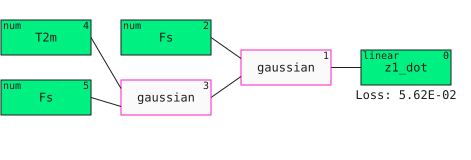

In [19]:
models_1 = train_qlattice_forcings(target='z1_dot', complexity=complexity, n_epochs=n_epochs)
models_1[0]

Training: 100%|███████████████████████████| 100/100 [08:36<00:00,  5.16s/it, R2=0.10136491060256958]


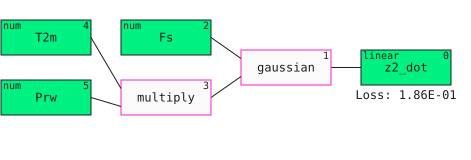

In [20]:
models_2 = train_qlattice_forcings(target='z2_dot', complexity=complexity, n_epochs=n_epochs)
models_2[0]

Training: 100%|███████████████████████████| 100/100 [08:40<00:00,  5.21s/it, R2=0.07112705707550049]


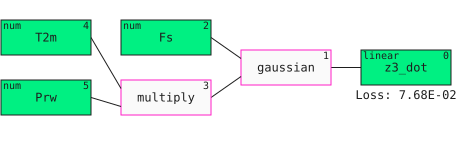

In [21]:
models_3 = train_qlattice_forcings(target='z3_dot', complexity=complexity, n_epochs=n_epochs)
models_3[0]

Training: 100%|███████████████████████████| 100/100 [08:28<00:00,  5.08s/it, R2=0.40371888875961304]


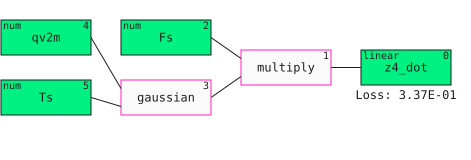

In [22]:
models_4 = train_qlattice_forcings(target='z4_dot', complexity=complexity, n_epochs=n_epochs)
models_4[0]

In [23]:
# Load forcings
def load_forcings(target):
    with open(f'forcings_target_{target}.pkl', 'rb') as file:
        models = pickle.load(file)
    return models

def display_forcing_equations():
    for target in ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']:
        # target = 'z1_dot'
        models = load_forcings(target)
        for i, m in enumerate(models):
            print(f'Variation {i}: {target} =', m.sympify(signif=2))
        print('\n')

display_forcing_equations()

Variation 0: z1_dot = 7.6*exp(-2.0*(0.017*Fs + 0.91)**2 - 2.0*exp(-4.0*(0.14*Fs + 0.038)**2 - 4.0*(1.8*T2m - 2.7)**2)) - 1.5
Variation 1: z1_dot = -0.095*Fs - 1.8*exp(-2.0*(3.3 - 2.2*T2m)**2 - 2.0*(0.19*Fs + 0.18)**2) + 0.015
Variation 2: z1_dot = -0.12*Fs - 1.1*exp(-2.0*(1.8 - 1.1*T2m)**2 - 2.0*(0.58*qv2m + 0.45)**2) + 0.023


Variation 3: z1_dot = 0.76 - 6.1*exp(-2.0*(0.11*Fs - 0.23)**2 - 2.0*tanh(18.0*exp(-2.3*T2m))**2)
Variation 4: z1_dot = -0.1*Fs - 1.1*exp(-2.0*(2.3 - 1.5*T2m)**2 - 2.0*(0.77*Fl - 0.85)**2) + 0.013
Variation 5: z1_dot = -0.11*Fs - 1.5*exp(-2.0*(-0.37*Prw - 0.55)**2 - 2.0*(1.4*T2m - 2.2)**2) + 0.019
Variation 6: z1_dot = 0.62 - 5.2*exp(-2.0*(0.27 - 0.12*Fs)**2 - 2.0*tanh((2.8 - 1.4*T2m)**2)**2)
Variation 7: z1_dot = -0.1*Fs - 2.1*exp(-2.0*(1.8*T2m - 3.0)**2 - 2.0*(0.77*Ts - 0.74)**2) + 0.015
Variation 8: z1_dot = -0.098*Fs - 2.2*exp(-2.0*(2.8 - 1.6*Ts)**2 - 2.0*(0.23*Fs + 0.19)**2) + 0.012
Variation 9: z1_dot = -0.13*Fs - 1.2*exp(-2.0*(0.54*Ts - 1.2)**2 - 2.0*(-0.46*qv2m - 0.56)**2) + 0.041


Variation 0: z2_dot = 3.6*exp(-2.0*(1.3 - 0.86*T2m)**2*(-0.96*Prw - 2.2)**2 - 2.0*(-0.25*Fs - 0.75)**2) - 0.022
Variation 1: z2_dot = 4.1*exp(-2.0*(1.4 - 0.81*T2m)**2*(0.46*qv2m + 1.8)**2 - 2.0*(-0.25*Fs - 0.77)**2) - 0.023
Variation 2: z2_dot = 4.6*exp(-2.0*(-0.26*Fs - 0.78)**2 - 2.0*(0.23*Prw - 1.3

In [24]:
# Select most promising variation. Favour bounded functions that are defined for all real numbers
selected_models = {}
for target, variation in zip(['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot'], [2, 3, 6, 7]):
    selected_models[target] = load_forcings(target)[variation]

In [25]:
# Make residuals
for target in ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']:
    model = selected_models[target]
    dzdt_train_res = model.predict(data_train[inputs])
    data_train[target + '_res'] = data_train[target] - dzdt_train_res
    dzdt_test_res = model.predict(data_test[inputs])
    data_test[target + '_res'] = data_test[target] - dzdt_test_res

In [30]:
best_models1 = train_qlattice('z1_dot_res')
with open('residuals_target_z1_dot.pkl', 'wb') as file:
    pickle.dump(best_models1, file)
best_models1[0]

Training: 100%|████████████████████████████| 100/100 [10:37<00:00,  6.38s/it, R2=0.5881476402282715]


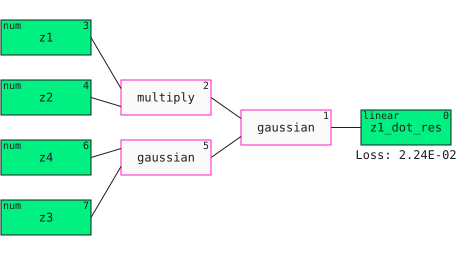

In [34]:
best_models1[0]

Training: 100%|████████████████████████████| 100/100 [10:33<00:00,  6.33s/it, R2=0.5493059158325195]


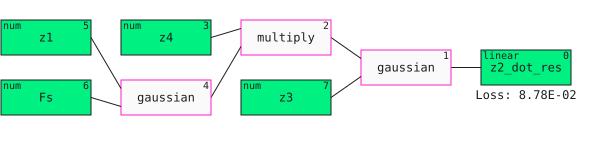

In [31]:
best_models2 = train_qlattice('z2_dot_res')
with open('residuals_target_z2_dot.pkl', 'wb') as file:
    pickle.dump(best_models2, file)
best_models2[0]

Training: 100%|███████████████████████████| 100/100 [10:48<00:00,  6.48s/it, R2=0.45229047536849976]


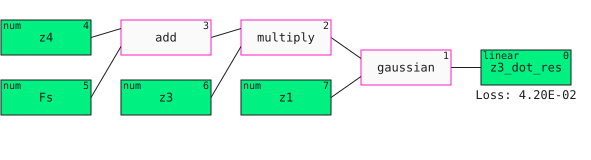

In [32]:
best_models3 = train_qlattice('z3_dot_res')
with open('residuals_target_z3_dot.pkl', 'wb') as file:
    pickle.dump(best_models3, file)
best_models3[0]

Training: 100%|███████████████████████████| 100/100 [10:25<00:00,  6.25s/it, R2=0.35896068811416626]


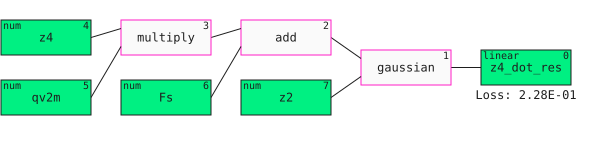

In [33]:
best_models4 = train_qlattice('z4_dot_res')
with open('residuals_target_z4_dot.pkl', 'wb') as file:
    pickle.dump(best_models4, file)
best_models4[0]

In [35]:
for target, best_models in zip(['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot'], [best_models1, best_models2, best_models3, best_models4]):
    for i, model in enumerate(best_models):
        print(f'Variation {i}: {target}_res = ', model.sympify(signif=2))
    print('\n')

Variation 0: z1_dot_res =  6.0*exp(-2.0*(-0.0052*z1 - 0.99)**2*(-0.011*z2 - 0.88)**2 - 2.0*exp(-4.0*(-0.019*z3 - 0.15)**2 - 4.0*(-0.0058*z4 - 0.82)**2)) - 1.2
Variation 1: z1_dot_res =  -0.017*z1 - 0.037*z2 - 1.3*exp(-2.0*(-0.028*z3 - 0.22)**2 - 2.0*(-0.011*z4 - 1.1)**2) + 0.04
Variation 2: z1_dot_res =  -0.017*z1 - 0.037*z2 - 1.3*exp(-2.0*(0.028*z3 + 0.22)**2 - 2.0*(-0.011*z4 - 1.1)**2) + 0.04
Variation 3: z1_dot_res =  5.3*exp(-2.0*(0.0047*z1 + 0.011*z2 + 0.84)**2 - 2.0*exp(-4.0*(0.021*z3 + 0.13)**2 - 4.0*(-0.006*z4 - 0.83)**2)) - 1.2
Variation 4: z1_dot_res =  16.0*exp(-2.0*(0.0079*z2 + 0.98)**2 - 2.0*(-0.0035*z4 + exp(-2.0*(0.13 - 0.14*T2m)**2 - 2.0*(0.011*z3 + 0.22)**2) - 0.44)**2) - 1.6
Variation 5: z1_dot_res =  -0.021*z1 + 4.4*exp(-2.0*(-0.009*z2 - 0.72)**2 - 2.0*exp(-4.0*(-0.14*T2m - 0.34)**2 - 4.0*(-0.0077*z4 - 0.91)**2)) - 1.6
Variation 6: z1_dot_res =  3.9*(0.013*z2 - 0.44)*(0.0092*z1 + exp(-2.0*(0.31*T2m + 0.28)**2 - 2.0*(-0.01*z4 - 1.3)**2) - 0.83) - 1.4
Variation 7: z1_d

In [36]:
# compute dz_1/dt = f(X) + g(X, Z)
best_res_model_z1dot = best_models1[0]
pred = selected_models['z1_dot'].predict(data_test[inputs]) + best_res_model_z1dot.predict(data_test[inputs])
feyn.metrics.r2_score(data_test['z1_dot'], pred)

np.float32(0.6589134)

In [37]:
best_res_model_z2dot = best_models2[2]
pred = selected_models['z2_dot'].predict(data_test[inputs]) + best_res_model_z2dot.predict(data_test[inputs])
feyn.metrics.r2_score(data_test['z2_dot'], pred)

np.float32(0.57289964)

In [38]:
best_res_model_z3dot = best_models3[1]
pred = selected_models['z3_dot'].predict(data_test[inputs]) + best_res_model_z3dot.predict(data_test[inputs])
feyn.metrics.r2_score(data_test['z3_dot'], pred)

np.float32(0.48728925)

In [39]:
# compute dz_1/dt = f(X) + g(X, Z)
best_res_model_z4dot = best_models4[0]
pred = selected_models['z4_dot'].predict(data_test[inputs]) + best_res_model_z4dot.predict(data_test[inputs])
feyn.metrics.r2_score(data_test['z4_dot'], pred)

np.float32(0.606053)

In [40]:
best_res_equations = []
for target, variation in zip(['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot'], [0, 2, 1, 0]):
    best_res_equations.append(best_models[0].sympify(signif=16) + selected_models[target].sympify(signif=16))

In [41]:
with open('nonlinear_ODE_residual_approach_4d_sympy_equations.pkl', 'wb') as file:
    pickle.dump(best_res_equations, file)

### Full Learning

Training: 100%|████████████████████████████| 100/100 [15:59<00:00,  9.59s/it, R2=0.6902908682823181]


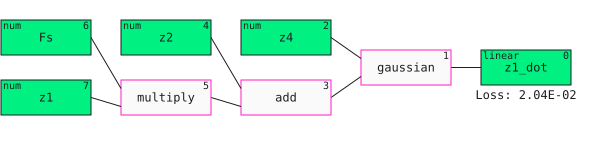

In [14]:
target, n_epochs, complexity = 'z1_dot', 100, 7
save_path = f'qlattice_equations/latent_dim=4_complexity={complexity}_n_epochs={n_epochs}_best_models_target={target}.pkl'
models_1 = train_qlattice(target, n_epochs=n_epochs, complexity=complexity, save_path=save_path)
models_1[0]

Training: 100%|█████████████████████████████| 100/100 [16:26<00:00,  9.86s/it, R2=0.601922333240509]


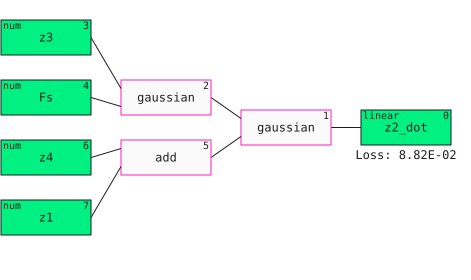

In [15]:
target, n_epochs, complexity = 'z2_dot', 100, 7
save_path = f'qlattice_equations/latent_dim=4_complexity={complexity}_n_epochs={n_epochs}_best_models_target={target}.pkl'
models_2 = train_qlattice(target, n_epochs=n_epochs, complexity=complexity, save_path=save_path)
models_2[0]

Training: 100%|████████████████████████████| 100/100 [16:20<00:00,  9.80s/it, R2=0.5199323892593384]


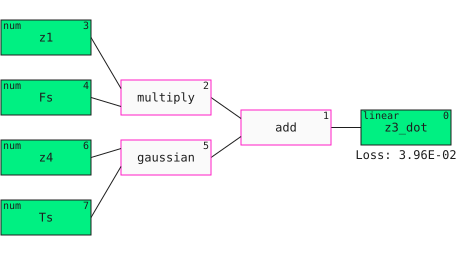

In [16]:
target, n_epochs, complexity = 'z3_dot', 100, 7
save_path = f'qlattice_equations/latent_dim=4_complexity={complexity}_n_epochs={n_epochs}_best_models_target={target}.pkl'
models_3 = train_qlattice(target, n_epochs=n_epochs, complexity=complexity, save_path=save_path)
models_3[0]

Training: 100%|█████████████████████████████| 100/100 [16:29<00:00,  9.89s/it, R2=0.601326584815979]


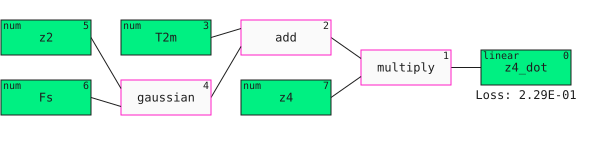

In [17]:
target, n_epochs, complexity = 'z4_dot', 100, 7
save_path = f'qlattice_equations/latent_dim=4_complexity={complexity}_n_epochs={n_epochs}_best_models_target={target}.pkl'
models_4 = train_qlattice(target, n_epochs=n_epochs, complexity=complexity, save_path=save_path)
models_4[0]

In [18]:
for target, best_models in zip(['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot'], [models_1, models_2, models_3, models_4]):
    for i, model in enumerate(best_models):
        print(f'Variation {i}: {target}_res = ', model.sympify(signif=2))
    print('\n')

Variation 0: z1_dot_res =  5.6*exp(-2.0*(0.0042*z4 - 0.28)**2 - 2.0*(0.0076*z2 + (0.51 - 0.0094*z1)*(0.064*Fs - 0.52) + 0.96)**2) - 1.9
Variation 1: z1_dot_res =  -3.5*(0.003*z4 + 0.54)*(0.022*z2 + (1.2 - 0.021*z1)*(0.081*Fs - 0.69) - 0.12) - 1.9
Variation 2: z1_dot_res =  -11.0*(1.2 - 0.016*z1)*(-0.011*z4 - 2.2)*exp(-2.0*(-0.019*Fs - 1.1)**2 - 2.0*(-0.0095*z2 - 0.44)**2) - 2.1
Variation 3: z1_dot_res =  15.0*(0.016*z1 - 1.2)*(-0.01*z4 - 2.0)*exp(-2.0*(-0.019*Fs - 1.1)**2 - 2.0*(0.0096*z2 + 0.44)**2) - 2.1
Variation 4: z1_dot_res =  7.9*(0.72 - 0.057*Fs)*(0.73 - 0.0089*z1)*exp(-2.0*(0.008*z2 + 0.5)**2 - 2.0*(0.0037*z4 - 0.28)**2) - 2.2
Variation 5: z1_dot_res =  8.2*(0.69 - 0.055*Fs)*(0.74 - 0.0092*z1)*exp(-2.0*(-0.008*z2 - 0.51)**2 - 2.0*(0.0038*z4 - 0.28)**2) - 2.2
Variation 6: z1_dot_res =  -10.0*(0.011*z1 - 0.84)*(0.0091*z4 + 1.8)*exp(-2.0*(-0.023*Fs - 0.88)**2 - 2.0*(-0.0093*z2 - 0.46)**2) - 2.1
Variation 7: z1_dot_res =  -9.9*(0.84 - 0.012*z1)*(0.03*z2 - 1.7)*exp(-2.0*(-0.022*Fs 

In [20]:
best_res_equations = []
for target, best_models, variation in zip(['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot'], [models_1, models_2, models_3, models_4], [0, 0, 0, 0]):
    best_res_equations.append(best_models[0].sympify(signif=16))

with open('nonlinear_ODE_4d_complexity=7_n_epochs=100_sympy_equations.pkl', 'wb') as file:
    pickle.dump(best_res_equations, file)

### Load data to pandas df

In [3]:
# XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5, 6]_latent_dims=3_past_timesteps=20/20251215092753_global_ocean_land_rp=False_eps=1.0_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
# XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5, 6]_latent_dims=3_past_timesteps=20/20251215092753_global_ocean_land_rp=False_eps=1.0_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260223103544_tropical_ocean_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260223103544_tropical_ocean_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')

In [3]:
def get_derivative(XZ, first_Z_ind):
    dm = ps.FiniteDifference()
    # dm = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 10})
    dZdt = np.array([dm._differentiate(Z[:, first_Z_ind:], t=1) for Z in XZ])
    return dZdt

In [25]:
# PySR data prep
latent_dims = 4
coord_skipper = None
tmin = None
tmax = None
time_skipper = None
#input_indices = [1, 2, 3, 4, 5, 6, -5, -4, -3, -2, -1]
input_indices = [1, 2, 3, 4, 5, 6, 7, -4, -3, -2, -1]
n_features = len(input_indices) - latent_dims

xz_train = XZ_train[::coord_skipper, tmin:tmax, input_indices]
xz_test = XZ_val[::, :, input_indices]

dZdt_train = get_derivative(xz_train, first_Z_ind=-latent_dims)
dZdt_train = dZdt_train[:, ::time_skipper].reshape(-1, latent_dims)
xz_train = xz_train[:, ::time_skipper].reshape(-1, latent_dims + n_features)
dZdt_test = get_derivative(xz_test, first_Z_ind=-latent_dims)
dZdt_test = dZdt_test[:, ::None].reshape(-1, latent_dims)
xz_test = xz_test[:, ::None].reshape(-1, latent_dims + n_features)

# 'ts', 'hfss', 'hfls', 'is_land',
# all_inputs = ['coord', 'qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'l', 'z1', 'z2', 'z3', 'z4', 'z5']
all_inputs = ['coord', 'qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'l', 'z1', 'z2', 'z3', 'z4']
inputs = [all_inputs[i] for i in input_indices]
print(inputs)
# feature_names = inputs + ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot', 'z5_dot']
feature_names = inputs + ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']
data_train = pd.DataFrame(np.concat((xz_train, dZdt_train), axis=1), columns=feature_names, dtype=np.float32)
data_test = pd.DataFrame(np.concat((xz_test, dZdt_test), axis=1), columns=feature_names, dtype=np.float32)

['qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'l', 'z1', 'z2', 'z3', 'z4']


In [26]:
for target in ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']:
    print(target)
    N_subsamples = 50_000
    subsample = np.random.choice(len(xz_train), size=N_subsamples)
    data_train = pd.DataFrame(np.concat((xz_train[subsample], dZdt_train[subsample]), axis=1), columns=feature_names, dtype=np.float32)
    priors = feyn.tools.estimate_priors(data_train[inputs + [target]], target)
    with open(f'qlattice_equations/latent_dim=4/priors/{region}_{surface}_priors_target={target}_Nsamples={N_subsamples}', 'wb') as file:
        pickle.dump(priors, file)

z1_dot


z2_dot
z3_dot
z4_dot


In [ ]:
priors = feyn.tools.estimate_priors(data_train[inputs + [target]], target)
priors

{'z3': np.float64(1.0),
 'z2': np.float64(0.99),
 'z1': np.float64(0.98),
 'Fl': np.float64(0.97),
 'Fs': np.float64(0.96),
 'z4': np.float64(0.95),
 'Prw': np.float64(0.94),
 'qv2m': np.float64(0.9299999999999999),
 'Ts': np.float64(0.92),
 'T2m': np.float64(0.91),
 'l': np.float64(0.9)}

In [10]:
with open(f'qlattice_equations/latent_dim=4/priors/{region}_{surface}_priors_target={target}_Nsamples={N_subsamples}', 'wb') as file:
    pickle.dump(priors, file)

In [ ]:
target = 'z1_dot'
ql = feyn.QLattice()
models = ql.auto_run(data_train[inputs + [target]], output_name=target, n_epochs=300, max_complexity=10)

,qv2m,Prw,T2m,Ts,Fs,Fl,z1,z2,z3,z4,z1_dot,z2_dot,z3_dot,z4_dot
0,1.307300,1.526327,0.865284,0.823026,0.184513,-0.428201,-0.075713,-0.808800,-0.718525,2.554261,0.026085,0.003242,-0.049344,-0.164633
1,1.364156,1.651283,0.857240,0.822896,0.167736,-0.331289,0.040912,-0.837391,-0.677793,1.501865,-0.010472,0.019905,0.000495,0.034902
2,1.303287,1.916312,0.774340,0.823000,-0.083366,-0.647899,-0.003727,-0.873849,-0.508867,1.937508,0.026521,0.003946,0.025017,-0.028275
3,1.308110,1.765392,0.802512,0.823126,0.093727,-0.198501,-0.185098,0.561948,-0.138211,0.230189,-0.054827,0.073778,-0.002551,0.109137
4,1.327160,1.846061,0.802775,0.823246,0.006841,-0.563001,-0.085675,-0.955285,-0.467689,1.810632,0.029308,-0.018246,0.012886,-0.155905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87735,-0.555657,-0.639887,-0.082586,0.194142,-0.689255,-1.098399,0.591484,1.125773,-6.914743,-1.951296,-0.049611,0.136110,0.053920,-0.363142
87736,-0.658403,-0.787018,-0.081149,0.193706,-0.976723,-1.973479,2.211331,-2.042696,-9.806596,0.370943,0.014534,0.359078,0.040917,-0.394704
87737,-0.692128,-0.756364,-0.092574,0.193249,-0.663253,-1.281278,0.771139,1.402074,-8.305639,1.620918,-0.146461,0.149734,0.166978,0.077471
87738,-0.592935,-0.804033,-0.142421,0.192774,-1.619921,-2.525597,2.953655,-2.511321,-11.302535,-1.972986,0.149677,-0.073137,-0.198079,0.152016


# Qlattice

In [8]:
base_dir = 'qlattice_equations/latent_dim=4/'
files = sorted(os.listdir(base_dir))
pattern = re.compile(r"my_qlattice_model_(.+)_(\d+)\.json")
parsed = []
for f in files:
    match = pattern.match(f)
    if match:
        X = match.group(1)        # string
        Y = int(match.group(2))   # int
        parsed.append([base_dir + f, X, Y, None])

In [9]:
for i in range(len(parsed)):
    path, target, ind, _ = parsed[i]
    model = Model.load(path)
    pred = model.predict(data_test[inputs])
    true = data_test[target].values
    parsed[i][-1] = feyn.metrics.r2_score(true, pred)
parsed = pd.DataFrame(parsed, columns=['path', 'target', 'ind', 'R2'])

Text(0, 0.5, '$R^2$ on test')

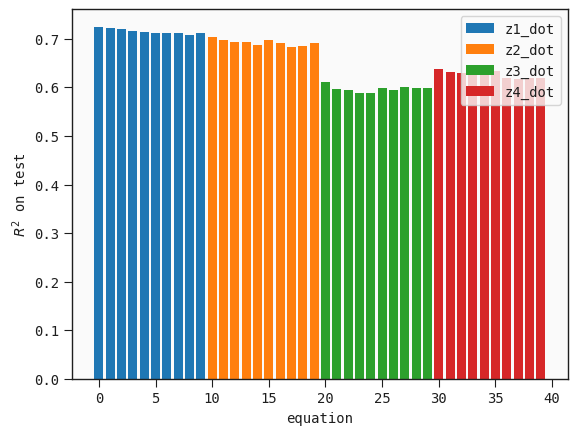

In [10]:
color_dict = {'z1_dot': 'tab:blue', 'z2_dot': 'tab:orange', 'z3_dot': 'tab:green', 'z4_dot': 'tab:red'}
parsed['color'] = parsed.target.map(color_dict)
handles = plt.bar(range(len(parsed)), parsed.R2, color=parsed.color)
plt.legend(handles[::10], parsed.target.values[::10])
plt.xlabel('equation')
plt.ylabel(r'$R^2$ on test')

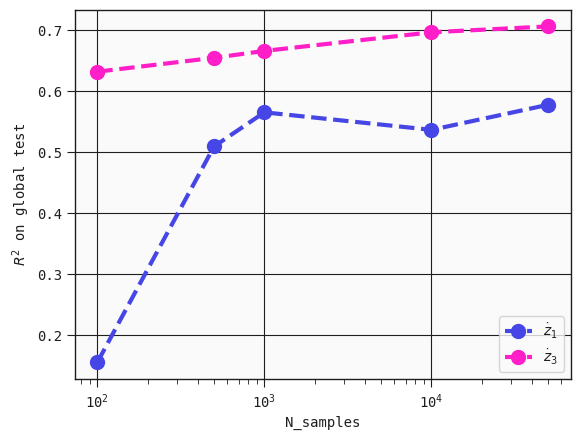

In [ ]:
subsamples = [100, 500, 1000, 10_000, 50_000]
z1_dot_R2 = [0.6323619, 0.65508723, 0.66642594, 0.6969969, 0.70661867]
z3_dot_R2 = [0.15552229, 0.50981045, 0.5656706, 0.5369351, 0.57810247]

plt.plot(subsamples, z3_dot_R2, marker='o', markersize=10, linestyle='--', label=r'$\dot{z}_1$')
plt.plot(subsamples, z1_dot_R2, marker='o', markersize=10, linestyle='--', label=r'$\dot{z}_3$')
plt.xlabel('N_samples training')
plt.ylabel(r'$R^2$ on global test')
plt.xscale('log')
plt.grid()
plt.legend()

### Convert Qlattice to Torch

In [8]:
from feyn import Model
import sympytorch
import pickle

base_dir = 'qlattice_equations/latent_dim=4/5mio_traindata_complexity=10/'
# base_dir = ''
model_z1 = Model.load(base_dir + 'my_qlattice_model_z1_dot_00.json')
model_z2 = Model.load(base_dir + 'my_qlattice_model_z2_dot_00.json')
model_z3 = Model.load(base_dir + 'my_qlattice_model_z3_dot_00.json')
model_z4 = Model.load(base_dir + 'my_qlattice_model_z4_dot_01.json')

models = [model_z1, model_z2, model_z3, model_z4]
models = [m.sympify(signif=16) for m in models]

with open('nonlinear_ODE_4d_sympy_equations.pkl', 'wb') as file:
    pickle.dump(models, file)

In [4]:
# Load data
XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
latent_dims = 4
input_indices = [1, 2, 3, 4, 5, 6, -4, -3, -2, -1]
n_features = len(input_indices) - latent_dims
XZ_train = XZ_train[:, :, input_indices]
XZ_val = XZ_val[:, :, input_indices]

# Compute targets
dZdt_train = get_derivative(XZ_train, first_Z_ind=-latent_dims)
dZdt_train = dZdt_train.reshape(-1, latent_dims)
XZ_train = XZ_train.reshape(-1, latent_dims + n_features)
dZdt_test = get_derivative(XZ_val, first_Z_ind=-latent_dims)
dZdt_test = dZdt_test.reshape(-1, latent_dims)
XZ_val = XZ_val.reshape(-1, latent_dims + n_features)

# Make subsample, keep entire validation set
n_sumbsample = 500_000
subsample = np.random.choice(len(XZ_train), size=n_sumbsample)
XZ_train = XZ_train[subsample]
dZdt_train = dZdt_train[subsample]

In [5]:
# Make train and test dataframes
all_inputs = ['coord', 'qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'l', 'z1', 'z2', 'z3', 'z4']
inputs = [all_inputs[i] for i in input_indices]
# feature_names = inputs + ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot', 'z5_dot']
feature_names = inputs + ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']
data_train = pd.DataFrame(np.concat((XZ_train, dZdt_train), axis=1), columns=feature_names, dtype=np.float32)
data_test = pd.DataFrame(np.concat((XZ_val, dZdt_test), axis=1), columns=feature_names, dtype=np.float32)

In [4]:
def convert_feyn_to_torch(model, data_train, data_test):
    '''
    model: Expects a feyn model -> sympytorch hybrid
    data_train: pandas Dataframe containing train data and all necessary inputs as well as target. Inputs/target are inferred from model. -> tensor training data expected from model (input, target)
    data_test: pandas Dataframe containing test data and all necessary inputs as well as target. Inputs/target are inferred from model. -> tensor test data expected from model (input, target)
    '''
    X_train = torch.tensor(data_train[model.inputs].values, device=device, dtype=torch.float32)
    Y_train = torch.tensor(data_train[model.output].values, device=device, dtype=torch.float32)
    X_test = torch.tensor(data_test[model.inputs].values, device=device, dtype=torch.float32)
    Y_test = torch.tensor(data_test[model.output].values, device=device, dtype=torch.float32)
    model_sympy = model.sympify(signif=9)
    model_sympy = sympytorch.SymPyModule(expressions=[model_sympy])
    model_sympy.to(device)
    return model_sympy, X_train, Y_train.reshape(-1, 1), X_test, Y_test.reshape(-1, 1)

In [5]:
def forward_from_tensor(sympy_model, X, input_names):
    """
    sympy_model: SymPyModule
    X: (N, D) tensor
    input_names: list of symbol names in order
    """
    kwargs = {
        name: X[:, i]
        for i, name in enumerate(input_names)
    }
    return sympy_model(**kwargs)

# Y_pred = forward_from_tensor(model, X_train, model_z1.inputs)

In [6]:
def get_symbols_targets_from_data(df, input_cols, target_cols):
    '''
    df: Expected to be a pandas Dataframe containing data for all necessary inputs/targets
    '''
    dtype = torch.float32
    # Collect inputs
    symbols = df[input_cols].to_dict(orient='list')  
    for key in symbols:
        symbols[key] = torch.tensor(symbols[key], device=device, dtype=dtype)  # symbols must map to tensors to run as pytorch models
    
    # Collect targets
    target = torch.tensor(df[target_cols].values, device=device, dtype=dtype)

    return symbols, target


def train(models, data_train, data_test, n_epochs=1000, signif=9):
    '''
    models: Expects a list of feyn models, where each element predicts one latent space variable derivative
    data_train: pandas Dataframe containing train data and all necessary inputs as well as targets. Inputs/targets are inferred from models
    data_test: pandas Dataframe containing test data and all necessary inputs as well as target. Inputs/targets are inferred from models
    '''
    # Convert feyn models to sympytorch and collect inputs/outputs
    models_sympy = sympytorch.SymPyModule(expressions=[m.sympify(signif=signif) for m in models])
    models_sympy.to(device)
    used_inputs = []
    used_targets = []
    for m in models:
        used_inputs += m.inputs
        used_targets += [m.output]
    used_inputs = list(set(used_inputs))  # remove duplicates and convert back to list as pandas indices can't be a set
    symbols_train, Y_train = get_symbols_targets_from_data(data_train, used_inputs, used_targets)
    symbols_test, Y_test = get_symbols_targets_from_data(data_test, used_inputs, used_targets)

    # Set ML training components
    pbar = trange(n_epochs, desc="Training", ncols=150)
    optimizer = torch.optim.Adam(models_sympy.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    R2 = R2Score(multioutput='raw_values')

    for epoch in pbar:
        # --- Train ---
        models_sympy.train()
        optimizer.zero_grad()
        Y_pred = models_sympy.forward(**symbols_train)
        loss = criterion(Y_pred, Y_train)
        loss.backward()
        optimizer.step()
        train_loss = loss.item()

        # --- Test ---
        models_sympy.eval()
        with torch.no_grad():
            Y_test_pred = models_sympy.forward(**symbols_test)
            test_loss = criterion(Y_test_pred, Y_test).item()
            r2_test = R2(Y_test_pred, Y_test)#.item()
        
        # --- Report ---
        pbar.set_postfix({
            "Train Loss": f"{train_loss:.4f}",
            "Val Loss": f"{test_loss:.4f}",

            "R2": f"{r2_test}"
            })
    
    return models_sympy

# models = [model_z1, model_z2, model_z3, model_z4]
# models_trained = train(models, data_train, data_test, signif=20)

### Integrate ODEs in time

In [27]:
base_dir = 'qlattice_equations/latent_dim=4/5mio_traindata_complexity=10/'
# base_dir = ''
model_z1 = Model.load(base_dir + 'my_qlattice_model_z1_dot_00.json')
model_z2 = Model.load(base_dir + 'my_qlattice_model_z2_dot_00.json')
model_z3 = Model.load(base_dir + 'my_qlattice_model_z3_dot_03.json')
model_z4 = Model.load(base_dir + 'my_qlattice_model_z4_dot_01.json')
model = [m.sympify(signif=16) for m in [model_z1, model_z2, model_z3, model_z4]]

In [28]:
#with open('linear_ODE_4d_sympy_equations.pkl', 'rb') as file:
with open('nonlinear_stable_ODE_4d_sympy_equations.pkl', 'wb') as file:
    #model = pickle.load(file)
    pickle.dump(model, file)


In [ ]:
with open('nonlinear_stable_ODE_4d_sympy_equations.pkl', 'rb') as file:
    m = pickle.load(file)

-35.15865559433469*exp(-2.0*(-0.037355022105822*Fs - 0.7093440618731787)**2 - 2.0*(0.006667300047484011*z4 - 0.1784001247584696)**2)*exp(-2.0*(-0.007714460368692055*z2 - 0.4651918291377361)**2 - 2.0*(-0.004956681908601931*z1 - 0.8527543976080361 + exp(-2.0*(0.03124098906023389*z3 - 1.317218287068161)**2))**2) + 2.007086443391832

In [15]:
for i, m in enumerate([model_z1, model_z2, model_z3, model_z4]):
    print(f'dz_{i+1}/dt = ', m.sympify(signif=3))

dz_1/dt =  11.3*exp(-2.0*(0.917*(1.69 - 0.029*z1)*exp(-2.0*(0.00999*z2 + 0.497)**2 - 2.0*(0.00387*z4 - 0.4)**2) - 0.997)**2 - 2.0*exp(-4.0*(0.0257*Fs - 0.265)**2 - 4.0*(0.00721*z3 + 0.0709)**2)) - 2.16
dz_2/dt =  4.76 - 18.9*exp(-2.0*(0.664 - 0.00361*z3)**2 - 2.0*exp(-4.0*(1.43*Fs - 2.94)**2*exp(-4.0*(0.00721*z1 + 0.922)**2 - 4.0*(0.00454*z4 - 0.468)**2) - 4.0*tanh(0.124*Fs + 0.533)**2))
dz_3/dt =  -35.2*exp(-2.0*(-0.0374*Fs - 0.709)**2 - 2.0*(0.00667*z4 - 0.178)**2)*exp(-2.0*(-0.00771*z2 - 0.465)**2 - 2.0*(-0.00496*z1 - 0.853 + exp(-2.0*(0.0312*z3 - 1.32)**2))**2) + 2.01
dz_4/dt =  2.42 - 17.9*exp(-2.0*(-0.0432*Fl + (0.562 - 0.047*z4)*exp(-2.0*(0.255 - 0.346*qv2m)**2 - 2.0*(0.379 - 0.142*Fs)**2) - 0.399)**2 - 2.0*exp(-4.0*(0.0104 - 0.0147*z2)**2))


In [13]:
for i in range(10):
    m = Model.load(base_dir + f'my_qlattice_model_z3_dot_0{i}.json')
    print(f'Variant {i+1}: ', m.sympify(signif=3))

Variant 1:  1.98 - 10.2*exp(-2.0*(0.00805*z4 - 0.0783)**2 - 2.0*exp(-4.0*(0.00367*z2 - 0.207)**2 - 4.0*log(0.00764*z1 + exp(-2.0*(0.688 - 0.0815*Fs)**2 - 2.0*(0.0164*z3 + 0.489)**2) + 0.658)**2))
Variant 2:  10.1*(0.718 - 0.00888*z2)*(0.0125*z1 - 0.699)*exp(-2.0*(0.196 - 0.00609*z4)**2 - 2.0*(-0.0414*Fs - 0.667)**2*tanh(0.0645*z3 - 1.71)**2) + 2.14
Variant 3:  17.6*(0.141*Fs - 1.13)*(-0.0129*z2 + tanh(0.0873*z3 - 1.46) + 1.78)*exp(-2.0*(0.199 - 0.00703*z4)**2 - 2.0*(0.00454*z1 + 1.04)**2) + 1.86
Variant 4:  -35.2*exp(-2.0*(-0.0374*Fs - 0.709)**2 - 2.0*(0.00667*z4 - 0.178)**2)*exp(-2.0*(-0.00771*z2 - 0.465)**2 - 2.0*(-0.00496*z1 - 0.853 + exp(-2.0*(0.0312*z3 - 1.32)**2))**2) + 2.01
Variant 5:  -19.4*(-0.35*Fs + exp(2.0*(0.473 - 0.00735*z2)**2 + 2.0*(0.0151*z3 + 0.375)**2) + 0.443)*exp(-2.0*(0.00399*z1 + 1.23)**2 - 2.0*(0.00608*z4 - 0.249)**2) + 2.01
Variant 6:  2.16 - 7.83*exp(-2.0*(0.00649*z4 - 0.172)**2 - 2.0*exp(-4.0*(0.658 - 0.0542*Fs)**2*(0.664 - 0.00917*z1)**2*(0.736 - 0.0071*z2)*

In [4]:
XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
latent_dims = 4
input_indices = [1, 2, 3, 4, 5, 6, -4, -3, -2, -1]
all_inputs = ['coord', 'qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'l', 'z1', 'z2', 'z3', 'z4']
inputs = [all_inputs[i] for i in input_indices]
feature_names = inputs + ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']
# This time we want to preserve the temporal order of the data
# To reduce the computational cost of training on the entire dataset, 
# we will make a subsample for training by skipping most coordinates keeping only every x, 
# but keep the entire validation set
coord_skipper = 5
coords_train = XZ_train[::coord_skipper, 0, 0].astype(int)
XZ_val = XZ_val[coords_train]
coords_test = XZ_val[:, 0, 0].astype(int)
precip_train = XZ_train[::coord_skipper, :, 8]
precip_test = XZ_val[:, :, 8]
n_features = len(input_indices) - latent_dims
XZ_train = XZ_train[::coord_skipper, :, input_indices]
XZ_val = XZ_val[:, :, input_indices]

# Compute targets
# dZdt_train = get_derivative(XZ_train, first_Z_ind=-latent_dims)
# dZdt_test = get_derivative(XZ_val, first_Z_ind=-latent_dims)

In [5]:
with open('linear_ODE_4d_sympy_equations.pkl', 'rb') as file:
    models_sympy = pickle.load(file)
models_sympy = sympytorch.SymPyModule(expressions=models_sympy)
models_sympy.to(device)
used_inputs = all_inputs
used_targets = ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot'] 

In [39]:
signif = 16
models = [model_z1, model_z2, model_z3, model_z4]
# Convert feyn models to sympytorch and collect inputs/outputs
models_sympy = sympytorch.SymPyModule(expressions=[m.sympify(signif=signif) for m in models])
models_sympy.to(device)
used_inputs = []
used_targets = []
for m in models:
    used_inputs += m.inputs
    used_targets += [m.output]
used_inputs = list(set(used_inputs))  # remove duplicates and convert back to list as pandas indices can't be a set
used_inputs

['z2', 'z1', 'Fl', 'z4', 'z3', 'qv2m', 'Fs']

In [7]:
XZ_train = torch.tensor(XZ_train, device=device, dtype=torch.float32)
XZ_val = torch.tensor(XZ_val, device=device, dtype=torch.float32)

In [8]:
XZ_combined = torch.cat((XZ_train, XZ_val), dim=1)
XZ_combined.shape

torch.Size([16384, 2507, 10])

In [12]:
dt = 1.0
tinit = 10
tmax = XZ_train.shape[1] - tinit - 1  
#tmax = 20
XZ_integrated = XZ_train.clone()  # to keep original data for comparison

for t in range(tinit, tinit+ tmax):  
    symbols = {
        name: XZ_integrated[:, t, i] for i, name in enumerate(inputs)
        }
    # Now we do one Euler step
    XZ_integrated[:, t+1, -latent_dims:] = XZ_integrated[:, t, -latent_dims:] + models_sympy.forward(**symbols) * dt 

diverged_coords = XZ_integrated[:, :, -latent_dims:].isnan().any(dim=1).any(dim=1)
print('Fraction of diverged coords = ', diverged_coords.sum() / diverged_coords.shape[0])

stable_coords_train = ~diverged_coords
Z_ODE_stable = XZ_integrated[stable_coords_train, tinit:, -latent_dims:]
Z_AE_stable = XZ_train[stable_coords_train, tinit:, -latent_dims:]

for i in range(4):
    print(f'dim {1+i}, R^2 = ', R2Score()(Z_ODE_stable[:, tmax, i].flatten(), Z_AE_stable[:, tmax, i].flatten()).item())

Fraction of diverged coords =  tensor(0.)
dim 1, R^2 =  0.3172857165336609
dim 2, R^2 =  0.2561730742454529
dim 3, R^2 =  0.7035050392150879
dim 4, R^2 =  -0.35267794132232666


In [10]:
dt = 1.0
tinit = 10
tmax = XZ_combined.shape[1] - tinit - 1  
# tmax = 400
XZ_full = XZ_combined.clone()  # to keep original data for comparison

for t in range(tinit, tinit+ tmax):  
    symbols = {
        name: XZ_full[:, t, i] for i, name in enumerate(inputs)
        }
    # Now we do one Euler step
    XZ_full[:, t+1, -latent_dims:] = XZ_full[:, t, -latent_dims:] + models_sympy.forward(**symbols) * dt 

diverged_coords_full = XZ_full[:, :, -latent_dims:].isnan().any(dim=1).any(dim=1)
print('Fraction of diverged coords = ', diverged_coords_full.sum() / diverged_coords_full.shape[0])
stable_coords_full = ~diverged_coords_full
Z_ODE_stable = XZ_full[stable_coords_full, tinit:, -latent_dims:]
Z_AE_stable = XZ_combined[stable_coords_full, tinit:, -latent_dims:]
for i in range(4):
    print(f'dim {1+i}, R^2 = ', R2Score()(Z_ODE_stable[..., i].flatten(), Z_AE_stable[..., i].flatten()).item())

Fraction of diverged coords =  tensor(0., device='cuda:0')
dim 1, R^2 =  0.4647454619407654
dim 2, R^2 =  0.6223207712173462
dim 3, R^2 =  0.6022121906280518
dim 4, R^2 =  -0.18217253684997559


In [14]:
dt = 1.0
tinit = 10
tmax = XZ_val.shape[1] - tinit - 1  
#tmax = 1000
XZ_integrated_test = XZ_val.clone()  # to keep original data for comparison

for t in range(tinit, tinit+ tmax):  
    symbols = {
        name: XZ_integrated_test[:, t, i] for i, name in enumerate(inputs)
        }
    # Now we do one Euler step
    XZ_integrated_test[:, t+1, -latent_dims:] = XZ_integrated_test[:, t, -latent_dims:] + models_sympy.forward(**symbols) * dt 

diverged_coords_test = XZ_integrated_test[:, :, -latent_dims:].isnan().any(dim=1).any(dim=1)
print('Fraction of diverged coords = ', diverged_coords_test.sum() / diverged_coords_test.shape[0])
stable_coords_test = ~diverged_coords_test
Z_ODE_stable = XZ_integrated_test[stable_coords_test, tinit:, -latent_dims:]
Z_AE_stable = XZ_val[stable_coords_test, tinit:, -latent_dims:]

for i in range(4):
    print(f'dim {1+i}, R^2 = ', R2Score()(Z_ODE_stable[..., i].flatten(), Z_AE_stable[..., i].flatten()).item())


Fraction of diverged coords =  tensor(0.)
dim 1, R^2 =  0.849557101726532
dim 2, R^2 =  0.776366651058197
dim 3, R^2 =  0.6812911629676819
dim 4, R^2 =  0.6189327836036682


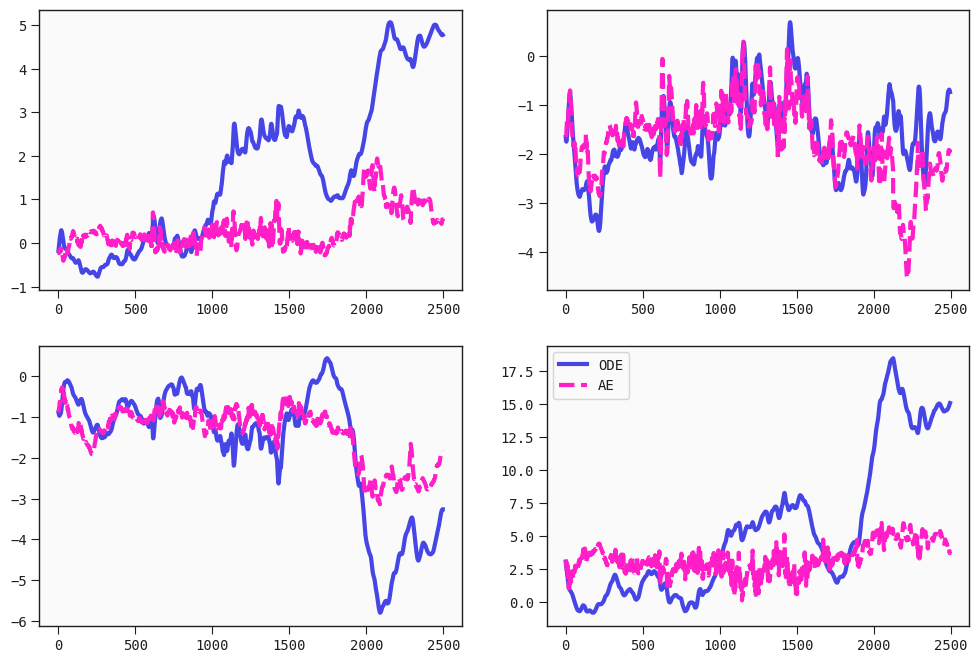

In [22]:
coord = 2348
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()
colors =['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, (ax, c) in enumerate(zip(axs, colors)):
    ax.plot(Z_ODE_stable[coord, :, i].cpu().detach().numpy(), label='ODE')
    ax.plot(Z_AE_stable[coord, :, i].cpu().detach().numpy(), label='AE', linestyle='--')
ax.legend()

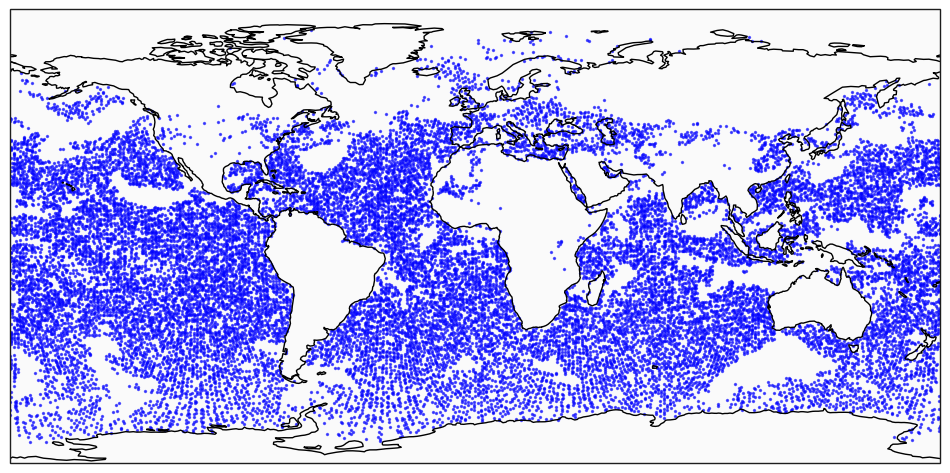

In [ ]:
ctr = coords_train[stable_coords_full.cpu().numpy()].astype(int)
lon = np.rad2deg(grid.clon.values)[ctr]
lat = np.rad2deg(grid.clat.values)[ctr]
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Adding map features
ax.coastlines(resolution='110m', linewidth=1)
scatter = ax.scatter(lon, lat, s=2, color='blue', alpha=0.6, 
                     transform=ccrs.PlateCarree(), label=f'')

In [16]:
precip_train = torch.tensor(precip_train, device=device, dtype=torch.float32)
precip_test = torch.tensor(precip_test, device=device, dtype=torch.float32)

In [70]:
class FCNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(FCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, output_dim)
        )
    def forward(self, x):
        return self.net(x)  
    
# Model classes
class BaseParametrization:
    def __init__(self, n_features, past_timesteps, latent_dims, memory_indices):
        super().__init__()

        # Parametrization params
        self.latent_dims = latent_dims
        self.past_timesteps = past_timesteps
        self.memory_indices = memory_indices
        if self.memory_indices:
            self.n_memory_features = len(self.memory_indices)
        else:
            self.n_memory_features = 0
        self.n_features = n_features
        self.model_name = None
        
        # training params
        self.weight_decay = None
        self.learning_rate = None
        self.train_loss = []
        self.val_loss = []
        self.test_loss = []
        self.R2 = []
        self.precip_val_loss = []
        self.recon_val_loss = []
    
    def save(self, additional_info=None):
        # Save the model
        if hasattr(self, 'X'):
            self.X = None  # remove data before saving

        save_dir = Path(f'networks/{self.model_name}/n_features={self.n_features}_memory_indices={self.memory_indices}_latent_dims={self.latent_dims}_past_timesteps={self.past_timesteps}')
        if not save_dir.exists(): 
            os.makedirs(save_dir) 
        
        timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
        if additional_info:
            save_file = f'{timestamp}_{additional_info}.pkl'
        else:
            save_file = f'{timestamp}.pkl'
        save_path = f'{save_dir}/{save_file}'
        torch.save(self, save_path)
        
        return save_path

class NN_ODE_single_time(nn.Module, BaseParametrization):
    def __init__(self, ODE, forcings, dt, n_features, past_timesteps, latent_dims, memory_indices, XZ, nodes_per_layer=16):
        nn.Module.__init__(self)
        BaseParametrization.__init__(self, n_features, past_timesteps, latent_dims, memory_indices,)
        
        self.nodes_per_layer = nodes_per_layer
        self.model_name = 'NN_ODE'
        self.ODE = ODE
        self.dt = dt
        # self.inputs = forcings + [f'z{i+1}' for i in range(latent_dims)]
        self.inputs = ['qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl'] + [f'z{i+1}' for i in range(latent_dims)]
        #forcings_dict = {'qv2m': 0, 'Prw': 1, 'T2m': 2, 'Ts': 3, 'Fs': 4, 'Fl': 5}
        #self.forcing_indices = [forcings_dict[f] for f in forcings]
        self.X = XZ#[..., self.forcing_indices]
        self.Z = XZ[..., -self.latent_dims:]

        self.neural_net = nn.Sequential(
            nn.Linear(latent_dims + self.n_features, self.nodes_per_layer), 
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )

        # Evaluation
        self.loss = []
        self.train_R2 = []
        self.test_R2 = []
        self.N_diverged_coords = []

    def integrate(self, Z0, c, t, tr):
        Z = Z0
        for t_integrate in range(t - tr, t):
            XZ = torch.cat((self.X[c, t_integrate, :-self.latent_dims], Z), dim=-1).T
            symbols = dict(zip(self.inputs, XZ))
            Z += self.ODE.forward(**symbols) * self.dt
        return Z

    def forward(self, c, t, tr):
        Z0 = self.Z[c, t-tr]
        print(Z0)
        Z = self.integrate(Z0, c, t, tr)
        # XZ = torch.cat((self.X[c, t, :-self.latent_dims], Z), dim=-1)
        # return self.neural_net(XZ)
        return Z

class NN_ODE_old(nn.Module, BaseParametrization):
    def __init__(self, ODE, forcings, dt, n_features, past_timesteps, latent_dims, memory_indices, XZ, nodes_per_layer=16):
        nn.Module.__init__(self)
        BaseParametrization.__init__(self, n_features, past_timesteps, latent_dims, memory_indices,)
        
        self.nodes_per_layer = nodes_per_layer
        self.model_name = 'NN_ODE'
        self.ODE = ODE
        self.dt = dt
        # self.inputs = forcings + [f'z{i+1}' for i in range(latent_dims)]
        self.inputs = ['qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl'] + [f'z{i+1}' for i in range(latent_dims)]
        self.N_inputs = len(self.inputs)
        #forcings_dict = {'qv2m': 0, 'Prw': 1, 'T2m': 2, 'Ts': 3, 'Fs': 4, 'Fl': 5}
        #self.forcing_indices = [forcings_dict[f] for f in forcings]
        self.X = XZ[..., :-self.latent_dims]
        self.Z = XZ[..., -self.latent_dims:]
        self.Z_ED = torch.zeros_like(self.Z)

        self.neural_net = nn.Sequential(
            nn.Linear(latent_dims + self.n_features, self.nodes_per_layer), 
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )

        # Evaluation
        self.loss = []
        self.train_R2 = []
        self.test_R2 = []
        self.N_diverged_coords = []

    def integrate(self, Z0, c, timesteps, t_rollout):
        Z = Z0
        for t_integrate in range(t_rollout, -1, -1):
            t_current = timesteps - t_integrate  # go backwards in time
            X = self.X[c][:, t_current]  # select past environmental state
            X = X.reshape(-1, self.n_features)  # reshape to batch dimension N_coord * N_timesteps
            XZ = torch.cat((X, Z), dim=-1).T  # concat X and Z together as ODE inputs, Transpose so variables are first dimension
            symbols = dict(zip(self.inputs, XZ))  # ODE expects sympy style input var1=X, var2=Y, ...
            Z += self.ODE.forward(**symbols) * self.dt  # Euler step
        return Z

    def forward(self, c, timesteps, tr):
        Z0 = self.Z[c][:, timesteps - tr]  # go back and select initial conditions for Z
        Z0 = Z0.reshape(-1, self.latent_dims)  # reshape to batch dimension N_coord * N_timesteps
        Z = self.integrate(Z0, c, timesteps, tr)  # integrate for tr Euler steps
        X = self.X[c][:, timesteps]  # get current environmental states
        X = X.reshape(-1, self.n_features)  # reshape to batch dimension N_coord * N_timesteps
        XZ = torch.cat((X, Z), dim=-1)  # concat current environmental state togehter with integrated Z as NN inputs
        # return self.neural_net(XZ)  # precip parametrization
        return Z

class NN_ODE(nn.Module, BaseParametrization):
    def __init__(self, ODE, forcings, dt, n_features, past_timesteps, latent_dims, memory_indices, XZ, nodes_per_layer=16):
        nn.Module.__init__(self)
        BaseParametrization.__init__(self, n_features, past_timesteps, latent_dims, memory_indices,)
        
        self.nodes_per_layer = nodes_per_layer
        self.model_name = 'NN_ODE'
        self.ODE = ODE
        self.dt = dt
        # self.inputs = forcings + [f'z{i+1}' for i in range(latent_dims)]
        self.inputs = ['qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl'] + [f'z{i+1}' for i in range(latent_dims)]
        self.N_inputs = len(self.inputs)
        #forcings_dict = {'qv2m': 0, 'Prw': 1, 'T2m': 2, 'Ts': 3, 'Fs': 4, 'Fl': 5}
        #self.forcing_indices = [forcings_dict[f] for f in forcings]
        self.X = XZ[..., :-self.latent_dims]
        self.Z_AE = XZ[..., -self.latent_dims:]
        self.Z_ED = torch.zeros_like(self.Z_AE)

        self.neural_net = nn.Sequential(
            nn.Linear(latent_dims + self.n_features, self.nodes_per_layer), 
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )

        # Evaluation
        self.loss = []
        self.train_R2 = []
        self.test_R2 = []
        self.N_diverged_coords = []

    def integrate(self, c, timesteps, t_rollout):
        Z = self.Z_AE[c][:, timesteps - t_rollout]  # start integration from AE latent state at t_rollout steps back in time
        Z = Z.reshape(-1, self.latent_dims)  # reshape to batch dimension N_coord * N_timesteps
        for t_integrate in range(t_rollout, -1, -1):
            t_current = timesteps - t_integrate  # go backwards in time
            X = self.X[c][:, t_current]  # select past environmental state
            X = X.reshape(-1, self.n_features)  # reshape to batch dimension N_coord * N_timesteps
            XZ = torch.cat((X, Z), dim=-1).T  # concat X and Z together as ODE inputs, Transpose so variables are first dimension
            symbols = dict(zip(self.inputs, XZ))  # ODE expects sympy style input var1=X, var2=Y, ...
            Z += self.ODE.forward(**symbols) * self.dt  # Euler step
            self.Z_ED[np.ix_(c, t_current)] = Z.reshape(len(c), len(t_current), self.latent_dims)
            #self.Z_ED[c][:, t_current] = Z.reshape(len(c), len(timesteps), self.latent_dims)
        return Z

    def forward(self, c, timesteps, tr):
        Z = self.integrate(c, timesteps, tr)  # integrate for tr Euler steps
        X = self.X[c][:, timesteps]  # get current environmental states
        X = X.reshape(-1, self.n_features)  # reshape to batch dimension N_coord * N_timesteps
        XZ = torch.cat((X, Z), dim=-1)  # concat current environmental state togehter with integrated Z as NN inputs
        # return self.neural_net(XZ)  # precip parametrization
        return Z

#models = [model_z1, model_z2, model_z3, model_z4]
# Convert feyn models to sympytorch and collect inputs/outputs
#models_sympy = sympytorch.SymPyModule(expressions=[m.sympify(signif=signif) for m in models])
# models_sympy.to(device)
# #model_precip = NN_ODE(models_sympy, ['Fl', 'qv2m', 'Fs'], dt=1, n_features=6, past_timesteps=20, latent_dims=4, memory_indices=None, XZ=XZ_combined)
model_precip = NN_ODE(models_sympy, used_inputs, dt=1, n_features=6, past_timesteps=20, latent_dims=4, memory_indices=None, XZ=XZ_train.clone())
model_precip.to(device)
# ts = np.arange(start=100, stop=400, step=100)
# print(ts)
ts = np.array([2110])
tr = 2000
coords = torch.where(stable_coords_train == True)[0]
Z = model_precip.forward(coords, ts, tr=tr)
Z

tensor([[ 12.0033,   2.6148,  -4.6324,  30.9726],
        [  8.5381,  -1.2804,  -7.4058,  24.5298],
        [  9.7057,   0.2739,  -8.4817,  23.8601],
        ...,
        [-23.9219,  11.7009,  18.1487, -88.7971],
        [  4.3600,   1.1746,  -9.4106,  14.9229],
        [  5.8427,   0.5289,  -8.2418,   1.9052]],
       grad_fn=<AsStridedBackward0>)

In [76]:
model_precip.Z_ED[:, 1000:, :]

tensor([[[  6.3920,   0.7458,  -3.5033,  19.7412],
         [  6.3965,   0.7553,  -3.5011,  19.7769],
         [  6.4007,   0.7602,  -3.4986,  19.8115],
         ...,
         [  0.0000,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000]],

        [[  3.5687,  -1.7071,  -3.0182,  10.0340],
         [  3.5485,  -1.6446,  -2.9878,  10.0665],
         [  3.5279,  -1.5797,  -2.9569,  10.0985],
         ...,
         [  0.0000,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000]],

        [[ 10.1524,  -0.1456,  -6.6685,  24.8033],
         [ 10.1544,  -0.1165,  -6.6549,  24.8123],
         [ 10.1551,  -0.0851,  -6.6388,  24.8224],
         ...,
         [  0.0000,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000]],

        ...,

        [[-23.8853, 

In [69]:
torch.where(stable_coords_train == True)[0]

tensor([    0,     1,     2,  ..., 16381, 16382, 16383])

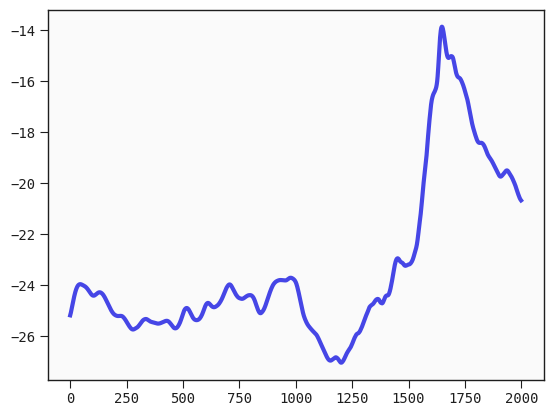

In [66]:
plt.plot(model_precip.Z_ED[coords][6, ts[0]-tr:ts[0], 0].cpu().detach().numpy(), label='ED')

In [55]:
model_precip.Z_ED[coords][0, 200:300, 0].cpu().detach().numpy()

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 1.1752741 , 1.1681604 , 1.1626002 ,
       1.158709  , 1.1565251 , 1.1561265 , 1.1573145 , 1.1596098 ,
       1.1623678 , 1.1657    , 1.169648  , 1.1740613 , 1.1788492 ,
       1.1839272 , 1.189178  , 1.1947573 , 1.2002106 , 1.2051681 ,
       1.2100356 , 1.2139876 , 1.2166767 , 1.2183268 , 1.2183075 ,
       1.2166935 , 1.2138927 , 1.2096215 , 1.204186  , 1.1971202 ,
       1.1889011 , 1.1786753 , 1.1664399 , 1.1522596 , 1.1366819 ,
       1.1203884 , 1.1033093 , 1.0855683 , 1.0674133 , 1.04900

In [49]:
(model_precip.Z_ED != 0.0).sum()

tensor(24012)

In [105]:
model_precip = NN_ODE_single_time(models_sympy, used_inputs, dt=1, n_features=6, past_timesteps=20, latent_dims=4, memory_indices=None, XZ=XZ_train.clone())
model_precip.to(device)
ts = 300
print(ts)

Z = model_precip.forward(np.array([1, 2, 3]), ts, tr=200)
Z

300
tensor([[ 1.0116, -0.5830, -1.2883,  1.4106],
        [-0.4075, -1.9077, -0.7483,  1.5977],
        [ 1.3131, -1.5110, -2.8087,  4.1702]])


tensor([[  2.7969,  -1.5007,  -4.3848,  11.7869],
        [  0.2609,  -0.8190,   0.6339,   0.7762],
        [  8.7924,   1.6045, -10.5953,  31.5546]], grad_fn=<AddBackward0>)

In [ ]:
tr = 2000
cs = np.arange(XZ_combined.shape[0])
t0 = 100
input_dim = XZ_combined.shape[-1]
output_dim = 1
#models_sympy = sympytorch.SymPyModule(expressions=[m.sympify(signif=signif) for m in models])
#models_sympy.to(device)
model_precip = NN_ODE(models_sympy, used_inputs, dt=1, n_features=6, past_timesteps=20, latent_dims=4, memory_indices=None, XZ=XZ_combined.clone())
model_precip = model_precip.to(device)
optimizer = torch.optim.Adam(model_precip.parameters(), lr=1e-3)
criterion = nn.MSELoss()
n_epochs = 100
pbar = trange(n_epochs, desc="Training FCNN for precip", ncols=150)
ttest = XZ_train.shape[1]
true = precip_train[cs, t0].reshape(-1, 1)
true_test = precip_test[cs, t0].reshape(-1, 1)
divergence_penalty = 1.e-5

for epoch in pbar:
    model_precip.train()
    optimizer.zero_grad()
    pred = model_precip.forward(cs, t0, tr)
    nan_mask = torch.isnan(pred)
    N_diverged_coords = nan_mask.sum()
    pred[nan_mask] = 0.0
    #true = model_precip.Z[cs, t0 + tr]
    
    loss = criterion(pred, true) + divergence_penalty * N_diverged_coords
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        pred_test = model_precip.forward(cs, t0 + ttest, tr)
        #true_test = model_precip.Z[cs, t0 + tr + ttest]
        R2_train = R2Score()(pred, true).item()
        R2_test = R2Score()(pred_test, true_test).item()
        model_precip.loss.append(loss.item())
        model_precip.train_R2.append(R2_train)
        model_precip.test_R2.append(R2_test)
        model_precip.N_diverged_coords.append(N_diverged_coords.item())

    pbar.set_postfix({
        "Loss": f"{loss.item():.4f}",
        "R2 train": f"{R2_train:.4f}",
        "R2 test": f"{R2_test:.4f}"
    })

Training FCNN for precip:   0%|                                                                                               | 0/100 [00:00<?, ?it/s]

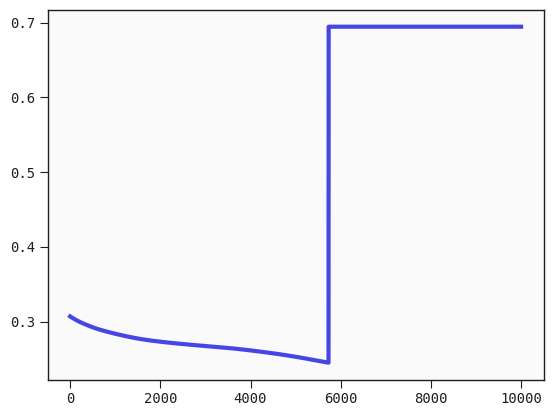

In [85]:
plt.plot(model_precip.loss)

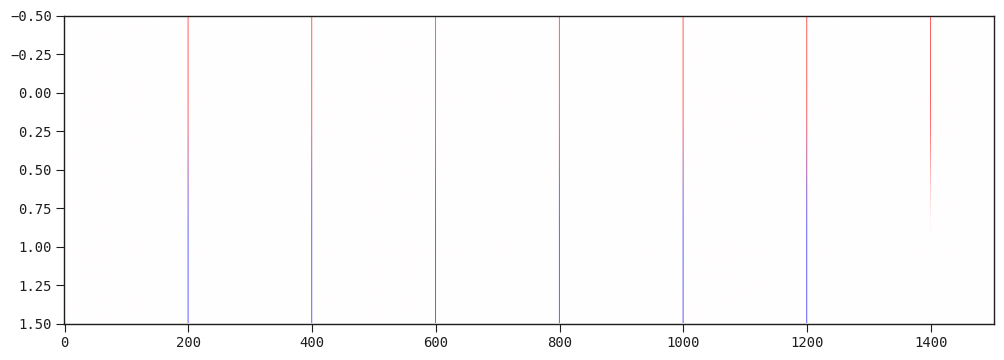

In [73]:
data = np.zeros((1503, 2))
tmax = len(data)
tr = 200
ts = np.arange(1, 1 + (tmax-1) // tr) * tr 
data[ts, 0] = 1
data[ts-tr, 1] = -1
plt.figure(figsize=(12, 4))
plt.imshow(data.T, aspect='auto', cmap='bwr')

In [52]:
27 // 3

9

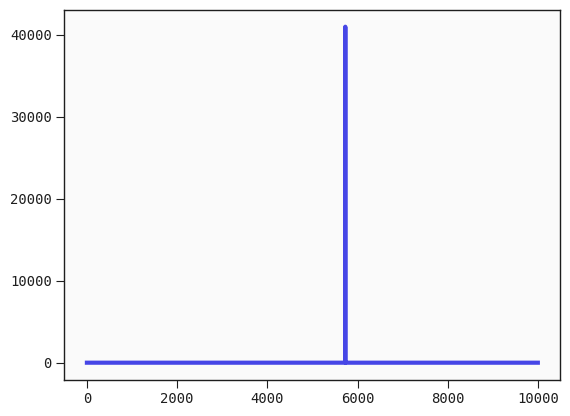

In [92]:
plt.plot(range(10_000 - 1), np.diff(model_precip.N_diverged_coords))
# plt.xlim(5000, 6000)
# plt.ylim(0, 100)

In [15]:
for p in models_sympy.parameters():
    print(p)

Parameter containing:
tensor(0.0129, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.0336, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.0347, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.0130, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.0162, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.0126, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.0725, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.0243, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.0067, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.0297, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.2283, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.3531, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.0978, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.3

In [13]:
c, t, tr = np.arange(40_000), 100, 10
Z0 = XZ_train[c, t-tr, -latent_dims:]
Z_target = XZ_train[c, t, -latent_dims:]
Z_pred = model_precip.integrate(Z0, c, t, tr)
R2Score(multioutput='raw_values')(Z_pred, Z_target)

tensor([0.9572, 0.6884, 0.8486, 0.9130], device='cuda:0',
       grad_fn=<CloneBackward0>)

In [122]:
stable_coords_full

tensor([ True, False,  True,  ...,  True,  True,  True], device='cuda:0')

In [89]:
rollout_times = [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 50, 60, 75, 100, 200, 300, 400, 500, 600, 700, 1000, 1500, 2000]
R2s = []
N_stable_coords = []
for tr in rollout_times:
    c, t = np.arange(0, XZ_train.shape[0]), 10
    #c, t = [1, 2, 3, 4, 5], 10
    Z0 = XZ_train[c, t-tr, -latent_dims:]
    Z_target = XZ_train[c, t, -latent_dims:]
    Z_pred = model_precip.integrate(Z0, c, t, tr)
    st_coords = ~Z_pred.isnan().any(dim=1)
    N_stable_coords.append(float(st_coords.sum() / len(st_coords)))
    R2 = R2Score(multioutput='raw_values')(Z_pred[st_coords], Z_target[st_coords]).detach().cpu().numpy()
    print(tr, R2)
    R2s.append(R2)

1 [0.9997738  0.998795   0.9987878  0.99933785]
2 [0.99918824 0.995462   0.99565023 0.99770325]
3 [0.9983771  0.99017    0.9910226  0.99533653]
4 [0.99740547 0.9831894  0.9854019  0.99243   ]
5 [0.9963229  0.9748486  0.97904176 0.9892015 ]
10 [0.9896114  0.9214898  0.93138546 0.9654415 ]
15 [0.76583904 0.09355509 0.02161628 0.4453134 ]
20 [ 0.7621011   0.05036616 -0.0187999   0.44536507]
30 [ 0.71353495 -0.04501331 -0.35165715  0.43089157]
40 [ 0.6426244  -0.08660793 -0.5287173   0.38892257]
50 [ 0.57849574 -0.18127286 -0.5684577   0.35061038]
60 [ 0.5307543  -0.3372271  -0.18277645  0.17531842]
75 [ 0.2954756 -0.8762684 -0.3118992 -0.54882  ]
100 [-0.4208039 -2.0633736 -3.3193355 -3.3063908]
200 [  -2.7853134 -171.79161   -162.67264    -46.5761   ]
300 [  -3.0682502 -658.4109    -785.4074    -163.56789  ]
400 [   -6.721287  -352.84857  -1133.0131    -223.89609 ]
500 [  -3.0661798 -228.03192   -414.24387    -58.502407 ]
600 [  -1.6654177 -154.8926    -175.86476    -17.103073 ]
700 [  -

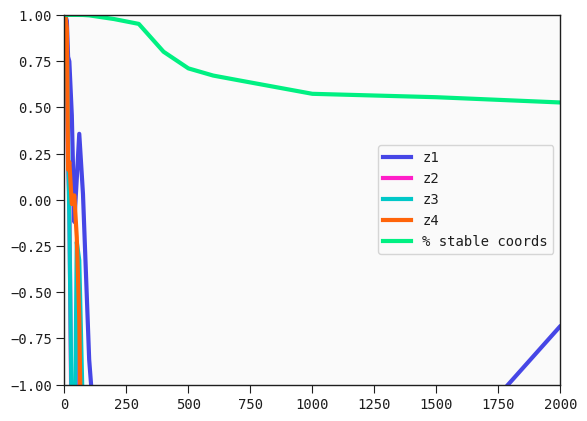

In [14]:
plt.plot(rollout_times, R2s, label=['z1', 'z2', 'z3', 'z4'])
plt.plot(rollout_times, N_stable_coords, label='% stable coords')
plt.ylim(-1, 1)
plt.xlim(0, 2000)
plt.legend()


In [14]:
c, t, tr = np.arange(XZ_train.shape[0]), 100, 2000
Z0 = XZ_train[c, t-tr, -latent_dims:]
Z_target = XZ_train[c, t-tr, -latent_dims:]
Z_pred = model.integrate(Z0, c, t, tr)
R2 = R2Score(multioutput='raw_values')(Z_pred, Z_target).detach().cpu().numpy()

In [15]:
st_coords = ~Z_pred.isnan().any(dim=1)
R2 = R2Score(multioutput='raw_values')(Z_pred[st_coords], Z_target[st_coords]).detach().cpu().numpy()
R2

array([  -0.23938775, -110.552635  ,  -22.309492  ,   -3.6839213 ],
      dtype=float32)

In [88]:
R2Score(multioutput='raw_values')(Z_pred, Z_target)

tensor([0.9965, 0.9734, 0.9891, 0.9943], device='cuda:0',
       grad_fn=<CloneBackward0>)

In [25]:
input_dim = XZ_combined.shape[-1]
output_dim = 1
model_precip = FCNN(input_dim, output_dim).to(device)
optimizer = torch.optim.Adam(model_precip.parameters(), lr=1e-3)
criterion = nn.MSELoss()
n_epochs = 3_000
pbar = trange(n_epochs, desc="Training FCNN for precip", ncols=150)
ttest = XZ_train.shape[1]
x = XZ_combined[stable_coords_full, tinit:ttest].reshape(-1, input_dim).detach()
x_test = XZ_combined[stable_coords_full, ttest:].reshape(-1, input_dim).detach()
true = precip_train[stable_coords_full, tinit:].reshape(-1, 1)
true_test = precip_test[stable_coords_full, :].reshape(-1, 1)
print(x.shape, x_test.shape, true.shape, true_test.shape)

for epoch in pbar:
    model_precip.train()
    optimizer.zero_grad()
    pred = model_precip(x)
    loss = criterion(pred, true)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        pred = model_precip(x)
        R2_train = R2Score()(pred, true).item()
        R2_test = R2Score()(model_precip(x_test), true_test).item()

    pbar.set_postfix({
        "Loss": f"{loss.item():.4f}",
        "R2 train": f"{R2_train:.4f}",
        "R2 test": f"{R2_test:.4f}"
    })

Training FCNN for precip:   0%|                                              | 0/3000 [00:00<?, ?it/s, Loss=0.3734, R2 train=-0.0228, R2 test=-0.0233]

torch.Size([34848768, 10]) torch.Size([6062080, 10]) torch.Size([34848768, 1]) torch.Size([6062080, 1])


Training FCNN for precip: 100%|█████████████████████████████████████| 3000/3000 [10:03<00:00,  4.97it/s, Loss=0.1213, R2 train=0.6668, R2 test=0.6519]


In [23]:
input_dim = XZ_full.shape[-1]
output_dim = 1
model_precip = FCNN(input_dim, output_dim).to(device)
optimizer = torch.optim.Adam(model_precip.parameters(), lr=1e-3)
criterion = nn.MSELoss()
n_epochs = 3_000
pbar = trange(n_epochs, desc="Training FCNN for precip", ncols=150)
ttest = XZ_train.shape[1]
x = XZ_full[stable_coords_full, tinit:ttest].reshape(-1, input_dim).detach()
x_test = XZ_full[stable_coords_full, ttest:].reshape(-1, input_dim).detach()
true = precip_train[stable_coords_full, tinit:].reshape(-1, 1)
true_test = precip_test[stable_coords_full, :].reshape(-1, 1)
print(x.shape, x_test.shape, true.shape, true_test.shape)

for epoch in pbar:
    model_precip.train()
    optimizer.zero_grad()
    pred = model_precip(x)
    loss = criterion(pred, true)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        pred = model_precip(x)
        R2_train = R2Score()(pred, true).item()
        R2_test = R2Score()(model_precip(x_test), true_test).item()

    pbar.set_postfix({
        "Loss": f"{loss.item():.4f}",
        "R2 train": f"{R2_train:.4f}",
        "R2 test": f"{R2_test:.4f}"
    })


Training FCNN for precip:   0%|                                                | 0/3000 [00:00<?, ?it/s, Loss=0.3646, R2 train=0.0024, R2 test=0.0022]

torch.Size([34848768, 10]) torch.Size([6062080, 10]) torch.Size([34848768, 1]) torch.Size([6062080, 1])


Training FCNN for precip: 100%|█████████████████████████████████████| 3000/3000 [10:03<00:00,  4.97it/s, Loss=0.1775, R2 train=0.5127, R2 test=0.4782]


In [24]:
# input_dim = XZ_integrated.shape[-1] - latent_dims
# print(input_dim)
# output_dim = 1
# model_precip = FCNN(input_dim, output_dim).to(device)
# optimizer = torch.optim.Adam(model_precip.parameters(), lr=1e-3)
# criterion = nn.MSELoss()
# n_epochs = 3_000
# pbar = trange(n_epochs, desc="Training FCNN for precip", ncols=150)
# x = XZ_integrated[:, tinit:, :-latent_dims].reshape(-1, input_dim).detach()
# x_test = XZ_integrated_test[:, tinit:, :-latent_dims].reshape(-1, input_dim).detach()
# true = precip_train[:, tinit:].reshape(-1, 1)
# true_test = precip_test[:, tinit:].reshape(-1, 1)
# print(x.shape, x_test.shape, true.shape, true_test.shape)

input_dim = XZ_combined.shape[-1] - latent_dims
output_dim = 1
model_precip = FCNN(input_dim, output_dim).to(device)
optimizer = torch.optim.Adam(model_precip.parameters(), lr=1e-3)
criterion = nn.MSELoss()
n_epochs = 3_000
pbar = trange(n_epochs, desc="Training FCNN for precip", ncols=150)
ttest = XZ_train.shape[1]
x = XZ_combined[stable_coords_full, tinit:ttest,:-latent_dims].reshape(-1, input_dim).detach()
x_test = XZ_combined[stable_coords_full, ttest:, :-latent_dims].reshape(-1, input_dim).detach()
true = precip_train[stable_coords_full, tinit:].reshape(-1, 1)
true_test = precip_test[stable_coords_full, :].reshape(-1, 1)
print(x.shape, x_test.shape, true.shape, true_test.shape)

for epoch in pbar:
    model_precip.train()
    optimizer.zero_grad()
    pred = model_precip(x)
    loss = criterion(pred, true)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        R2_train = R2Score()(pred, true).item()
        pred_test = model_precip(x_test)
        loss_test = criterion(pred_test, true_test).item()
        R2_test = R2Score()(pred_test, true_test).item()

    pbar.set_postfix({
        "Loss": f"{loss.item():.4f}",
        "test Loss": f"{loss_test:.4f}",
        "R2 train": f"{R2_train:.4f}",
        "R2 test": f"{R2_test:.4f}"
    })


Training FCNN for precip:   0%|                    | 1/3000 [00:00<07:46,  6.43it/s, Loss=0.4481, test Loss=0.4520, R2 train=-0.2307, R2 test=-0.2221]

torch.Size([34848768, 6]) torch.Size([6062080, 6]) torch.Size([34848768, 1]) torch.Size([6062080, 1])


Training FCNN for precip: 100%|███████████████████| 3000/3000 [07:34<00:00,  6.61it/s, Loss=0.1792, test Loss=0.1922, R2 train=0.5078, R2 test=0.4805]


In [14]:
XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_train = torch.tensor(XZ_train[::5], device=device, dtype=torch.float32)
XZ_val = torch.tensor(XZ_val, device=device, dtype=torch.float32)
latent_dims = 4
input_indices = [1, 2, 3, 4, 5, 6, -4, -3, -2, -1]
precip = XZ_train[:, :, 8].reshape(-1, 1)
precip_test = XZ_val[:, :, 8].reshape(-1, 1)
XZ_train = XZ_train[:, :, input_indices].reshape(-1, len(input_indices))
XZ_val = XZ_val[:, :, input_indices].reshape(-1, len(input_indices))

In [15]:
model_precip = FCNN(len(input_indices), 1).to(device)
optimizer = torch.optim.Adam(model_precip.parameters(), lr=1e-3)
criterion = nn.MSELoss()
n_epochs = 3_000
pbar = trange(n_epochs, desc="Training FCNN for precip", ncols=150)

for epoch in pbar:
    model_precip.train()
    optimizer.zero_grad()
    pred = model_precip(XZ_train)
    loss = criterion(pred, precip)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        R2_train = R2Score()(pred, precip).item()
        pred_test = model_precip(XZ_val)
        loss_test = criterion(pred_test, precip_test).item()
        R2_test = R2Score()(pred_test, precip_test).item()

    pbar.set_postfix({
        "Loss": f"{loss.item():.4f}",
        "test Loss": f"{loss_test:.4f}",
        "R2 train": f"{R2_train:.4f}",
        "R2 test": f"{R2_test:.4f}"
    })

Training FCNN for precip:  89%|████████████████▉  | 2670/3000 [07:52<00:58,  5.65it/s, Loss=0.1246, test Loss=0.1327, R2 train=0.6574, R2 test=0.6414]


KeyboardInterrupt: 

In [13]:
model_precip = FCNN(len(input_indices), 1).to(device)
optimizer = torch.optim.Adam(model_precip.parameters(), lr=1e-3)
criterion = nn.MSELoss()
n_epochs = 3_000
pbar = trange(n_epochs, desc="Training FCNN for precip", ncols=150)

for epoch in pbar:
    model_precip.train()
    optimizer.zero_grad()
    pred = model_precip(XZ_train)
    loss = criterion(pred, precip)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        R2_train = R2Score()(pred, precip).item()
        pred_test = model_precip(XZ_val)
        loss_test = criterion(pred_test, precip_test).item()
        R2_test = R2Score()(pred_test, precip_test).item()

    pbar.set_postfix({
        "Loss": f"{loss.item():.4f}",
        "test Loss": f"{loss_test:.4f}",
        "R2 train": f"{R2_train:.4f}",
        "R2 test": f"{R2_test:.4f}"
    })

Training FCNN for precip:  69%|█████████████      | 2069/3000 [06:05<02:44,  5.66it/s, Loss=0.1843, test Loss=0.1960, R2 train=0.4932, R2 test=0.4703]


KeyboardInterrupt: 

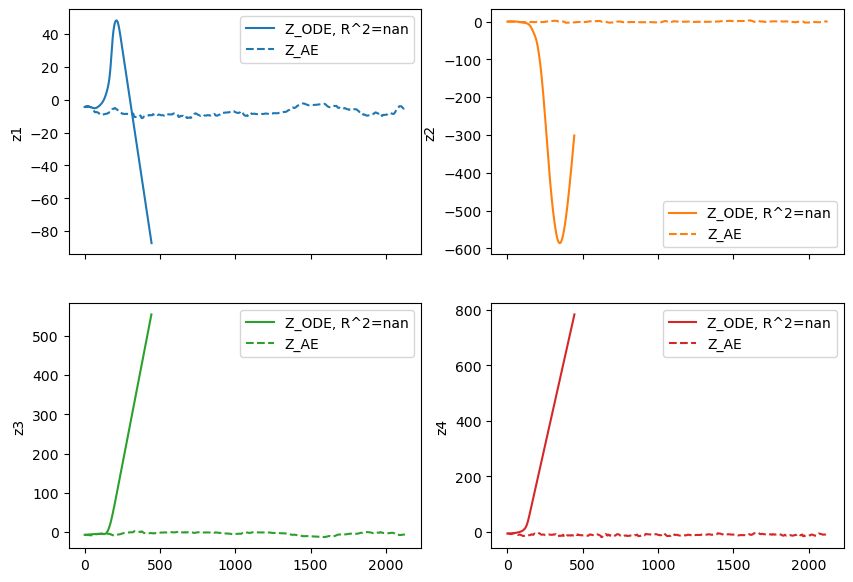

In [140]:
# Reset to default matplotlib style for better visibility of differences
plt.style.use('default')
Z_integrated = XZ_integrated[:, tinit:, -latent_dims:].cpu().detach().numpy()
Z_original = XZ_train[:, tinit:, -latent_dims:].cpu().detach().numpy()
coord = 239
fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axs = axs.flatten()
colors =['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, (c, ax) in enumerate(zip(colors, axs)):
    R2 = R2Score()(torch.tensor(Z_integrated[coord, :, i]), torch.tensor(Z_original[coord, :, i]))
    ax.plot(Z_integrated[coord, :, i], color=c, label=f'Z_ODE, R^2={R2:.2f}')
    ax.plot(Z_original[coord, :, i], color=c, linestyle='--', label='Z_AE')
    ax.set(ylabel=f'z{i+1}')
    ax.legend()
    

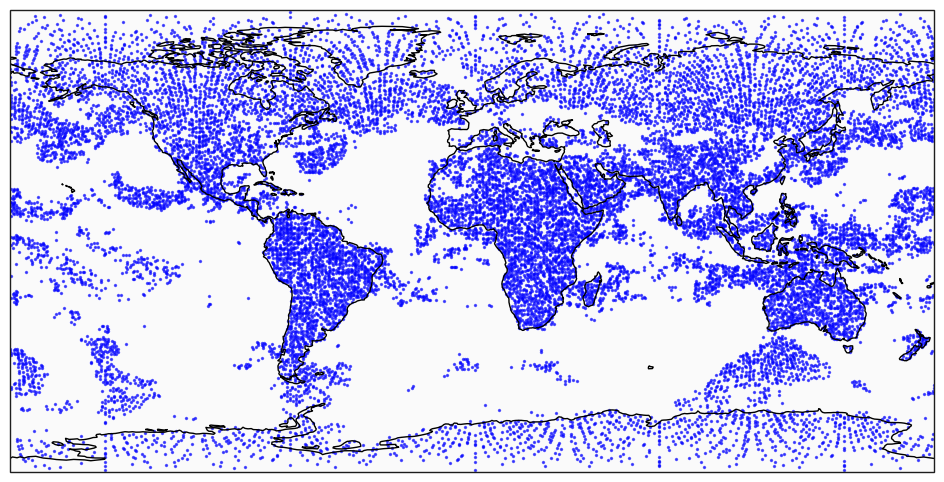

In [15]:
# Which coordinates diverge?
lon = np.rad2deg(grid.clon.values)[coords_train[diverged_coords.cpu().numpy()].astype(int)]
lat = np.rad2deg(grid.clat.values)[coords_train[diverged_coords.cpu().numpy()].astype(int)]
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Adding map features
ax.coastlines(resolution='110m', linewidth=1)
scatter = ax.scatter(lon, lat, s=2, color='blue', alpha=0.6, 
                     transform=ccrs.PlateCarree(), label=f'Unstable coordinates')

In [57]:
precip_train.shape

torch.Size([8192, 2137])

(81920,) (81920,) (81920,)


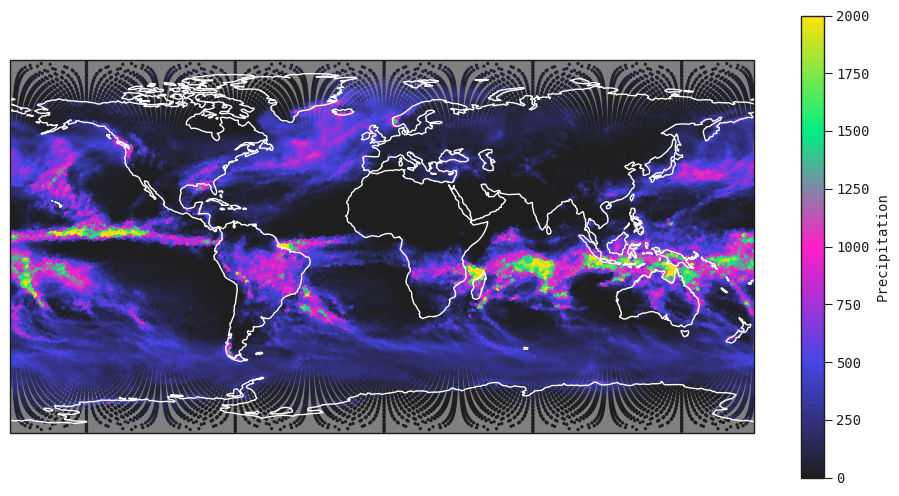

In [16]:
# Which coordinates diverge?
lon = np.rad2deg(grid.clon.values)[coords_train.astype(int)]
lat = np.rad2deg(grid.clat.values)[coords_train.astype(int)]
precip = np.sum(precip_train, axis=1)#[coords_train.astype(int)]
print(lon.shape, lat.shape, precip.shape)
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor('gray')
# 3. Adding map features
ax.coastlines(resolution='110m', linewidth=1, color='white')
scatter = ax.scatter(lon, lat, s=2, c=precip, alpha=1.0, vmin=0, vmax=2000,
                     transform=ccrs.PlateCarree(), label=f'Precipitation')
fig.colorbar(scatter, ax=ax, label='Precipitation')

In [36]:
all_inputs = ['coord', 'qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'l', 'z1', 'z2', 'z3', 'z4']
inputs = [all_inputs[i] for i in input_indices]
# feature_names = inputs + ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot', 'z5_dot']
feature_names = inputs + ['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']
pd.DataFrame(XZ_train[:, 20]).to_dict(orient='list').keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [149]:
models = [model_z3]
models_sympy = sympytorch.SymPyModule(expressions=[m.sympify(signif=9) for m in models])
models_sympy.to(device)
used_inputs = []
used_targets = []
for m in models:
    used_inputs += m.inputs
    used_targets += [m.output]
used_inputs = list(set(used_inputs))  # remove duplicates and convert back to list as pandas indices can't be a set
print(used_inputs, used_targets)
symbols_train, Y_train = get_symbols_targets_from_data(data_train, used_inputs, used_targets)
symbols_test, Y_test = get_symbols_targets_from_data(data_test[::200], used_inputs, used_targets)
R2 = R2Score(multioutput='raw_values')

models_sympy.eval()
with torch.no_grad():
    Y_test_pred = models_sympy.forward(**symbols_test)
    r2_test = R2(Y_test_pred, Y_test)#.item()
r2_test

['Fs', 'z1', 'z3', 'z4', 'z2'] ['z3_dot']


tensor(0.6022, device='cuda:0')

In [111]:
symbols_test['Fs'].cpu().numpy()

array([ 1.1382902 ,  0.7043959 , -0.12036403, ..., -0.20022686,
        0.53305984, -0.4537101 ], shape=(151552,), dtype=float32)

In [159]:
symbols_test_np = {}

for key in symbols_test.keys():
    print(key)
    symbols_test_np[key] = np.array(symbols_test[key].cpu().numpy()).T
X_test_df = pd.DataFrame(symbols_test_np)
X_test_df_data = data_test[::200][model_z3.inputs]

Fs
z1
z3
z4
z2


In [160]:
X_test_df_data.columns

Index(['Fs', 'z1', 'z2', 'z3', 'z4'], dtype='object')

In [161]:
models_sympy.forward(**symbols_test)[:10]

tensor([[-0.0493],
        [-0.1569],
        [-0.0367],
        [ 0.3084],
        [-0.0078],
        [ 0.0119],
        [-0.1383],
        [ 0.0077],
        [-0.1903],
        [ 0.1580]], device='cuda:0', grad_fn=<SliceBackward0>)

In [162]:
model_z3.predict(X_test_df)[:10]

array([-0.04927751, -0.15690728, -0.03674432,  0.30843234, -0.00780957,
        0.01187325, -0.13829179,  0.00772572, -0.19033088,  0.15798901],
      dtype=float32)

In [129]:
model_z4.predict(X_test_df_data)

array([ 0.00794112, -0.01093583, -0.02369669, ..., -0.03434367,
        0.07087599, -0.03479546], shape=(151552,), dtype=float32)

In [98]:
print(model_z4.inputs)
print(model_z4.output)

['Fs', 'qv2m', 'z2', 'z4']
z4_dot


In [17]:
def train(model, data_train, data_test, n_epochs=2000):
    '''
    model: Expects a feyn model -> sympytorch hybrid
    data_train: pandas Dataframe containing train data and all necessary inputs as well as target. Inputs/target are inferred from model. -> tensor training data expected from model (input, target)
    data_test: pandas Dataframe containing test data and all necessary inputs as well as target. Inputs/target are inferred from model. -> tensor test data expected from model (input, target)
    '''
    model_sympy, X_train, Y_train, X_test, Y_test = convert_feyn_to_torch(model, data_train, data_test)
    pbar = trange(n_epochs, desc="Training", ncols=150)
    optimizer = torch.optim.Adam(model_sympy.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    R2 = R2Score()

    for epoch in pbar:
        model_sympy.train()
        optimizer.zero_grad()
        Y_pred = forward_from_tensor(model_sympy, X_train, model.inputs)
        loss = criterion(Y_pred, Y_train)
        loss.backward()
        optimizer.step()
        train_loss = loss.item()

        model_sympy.eval()
        with torch.no_grad():
            Y_test_pred = forward_from_tensor(model_sympy, X_test, model.inputs)
            test_loss = criterion(Y_test_pred, Y_test).item()
            r2_test = R2(Y_test_pred, Y_test).item()
        
        pbar.set_postfix({
            "Train Loss": f"{train_loss}",
            "Val Loss": f"{test_loss}",

            "R2": f"{r2_test:.4f}"
            })

train(model_z4, data_train, data_test)

Training:  21%|██████                      | 429/2000 [03:06<11:22,  2.30it/s, Train Loss=0.2648862898349762, Val Loss=0.29101938009262085, R2=0.5411]


KeyboardInterrupt: 

<?xml version="1.0" encoding="utf-8" ?>
<svg baseProfile="full" height="264.0" preserveAspectRatio="none" version="1.1" viewBox="0 0 1115 264.0" width="1115" xmlns="http://www.w3.org/2000/svg" xmlns:ev="http://www.w3.org/2001/xml-events" xmlns:xlink="http://www.w3.org/1999/xlink"><defs /><svg class="graph" height="155.0" width="831" x="0" y="0"><defs /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="721" y="50.0"><title>z1_dot
linear:
scale=2.613120
scale offset=0.000000
w=3.533257
bias=-1.0928</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="766.0" y="71.5">z1_dot</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="809" y="59.0">0</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="723" y="59.0">linear</text><line stroke="#1E1E1E" x1="691" x2="721" y1="67.5" y2="67.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="601" y="50.0"><title>gaussian</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="646.0" y="71.5">gaussian</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="689" y="59.0">1</text><line stroke="#1E1E1E" x1="571" x2="601" y1="37.5" y2="58.5" /><line stroke="#1E1E1E" x1="571" x2="601" y1="97.5" y2="76.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="481" y="20.0"><title>z4
linear:
scale=0.011826
scale offset=-9.178383
w=0.214989
bias=-0.4719</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="526.0" y="41.5">z4</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="569" y="29.0">2</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="483" y="29.0">num</text><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="481" y="80.0"><title>gaussian</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="526.0" y="101.5">gaussian</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="569" y="89.0">3</text><line stroke="#1E1E1E" x1="451" x2="481" y1="37.5" y2="88.5" /><line stroke="#1E1E1E" x1="451" x2="481" y1="97.5" y2="106.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="361" y="20.0"><title>multiply</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="406.0" y="41.5">multiply</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="449" y="29.0">4</text><line stroke="#1E1E1E" x1="331" x2="361" y1="37.5" y2="28.5" /><line stroke="#1E1E1E" x1="331" x2="361" y1="97.5" y2="46.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="241" y="20.0"><title>tanh</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="41.5">tanh</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="29.0">5</text><line stroke="#1E1E1E" x1="211" x2="241" y1="67.5" y2="37.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="121" y="50.0"><title>multiply</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="166.0" y="71.5">multiply</tex
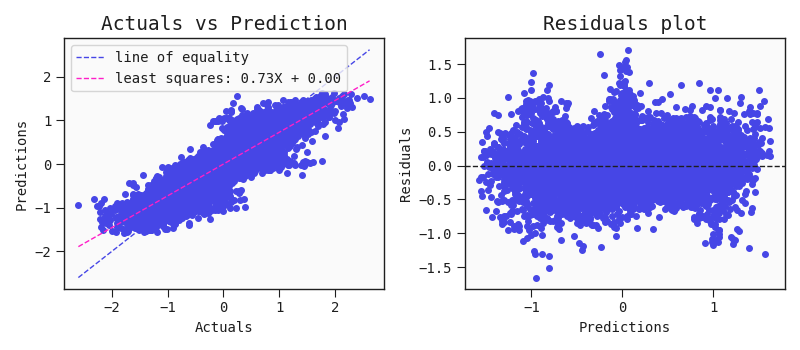
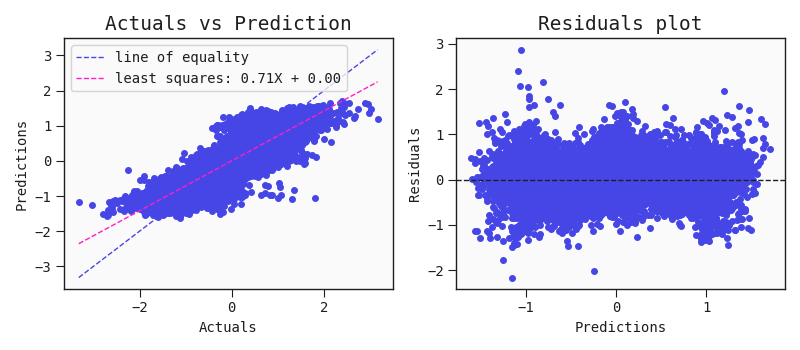

In [10]:
target, model = 'z1_dot', model_z1
model.plot(
    data=data_train[inputs + [target]],
    compare_data=data_test[inputs + [target]]
)

<?xml version="1.0" encoding="utf-8" ?>
<svg baseProfile="full" height="248.0" preserveAspectRatio="none" version="1.1" viewBox="0 0 1101 248.0" width="1101" xmlns="http://www.w3.org/2000/svg" xmlns:ev="http://www.w3.org/2001/xml-events" xmlns:xlink="http://www.w3.org/1999/xlink"><defs /><svg class="graph" height="155.0" width="831" x="0" y="0"><defs /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="721" y="50.0"><title>z2_dot
linear:
scale=4.797210
scale offset=0.000000
w=0.692384
bias=0.2381</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="766.0" y="71.5">z2_dot</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="809" y="59.0">0</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="723" y="59.0">linear</text><line stroke="#1E1E1E" x1="691" x2="721" y1="67.5" y2="67.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="601" y="50.0"><title>add</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="646.0" y="71.5">add</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="689" y="59.0">1</text><line stroke="#1E1E1E" x1="571" x2="601" y1="37.5" y2="58.5" /><line stroke="#1E1E1E" x1="571" x2="601" y1="97.5" y2="76.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="481" y="20.0"><title>tanh</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="526.0" y="41.5">tanh</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="569" y="29.0">2</text><line stroke="#1E1E1E" x1="451" x2="481" y1="67.5" y2="37.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="361" y="50.0"><title>multiply</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="406.0" y="71.5">multiply</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="449" y="59.0">3</text><line stroke="#1E1E1E" x1="331" x2="361" y1="37.5" y2="58.5" /><line stroke="#1E1E1E" x1="331" x2="361" y1="97.5" y2="76.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="241" y="20.0"><title>Fs
linear:
scale=0.100942
scale offset=-0.025870
w=3.272321
bias=-0.4721</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="41.5">Fs</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="29.0">4</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="243" y="29.0">num</text><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="241" y="80.0"><title>add</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="101.5">add</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="89.0">5</text><line stroke="#1E1E1E" x1="211" x2="241" y1="37.5" y2="88.5" /><line stroke="#1E1E1E" x1="211" x2="241" y1="97.5" y2="106.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="121" y="20.0"><title>multiply</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="166.0" y="41.5">multiply</text><text fill="#1E1E1E
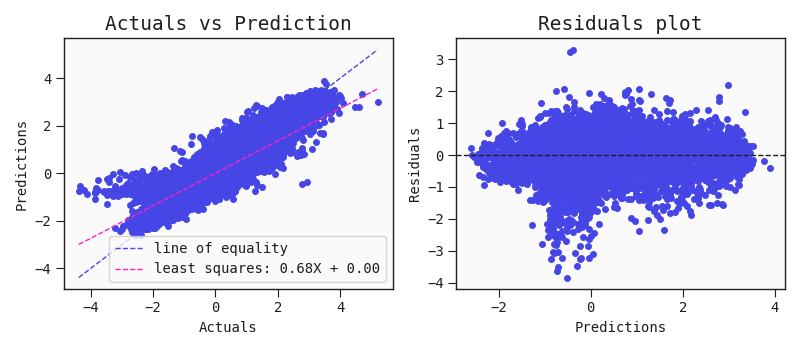
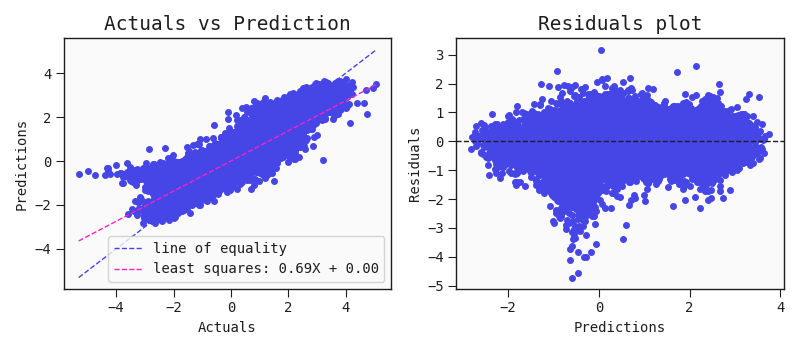

In [11]:
target, model = 'z2_dot', model_z2
model.plot(
    data=data_train[inputs + [target]],
    compare_data=data_test[inputs + [target]]
)

<?xml version="1.0" encoding="utf-8" ?>
<svg baseProfile="full" height="324.0" preserveAspectRatio="none" version="1.1" viewBox="0 0 981 324.0" width="981" xmlns="http://www.w3.org/2000/svg" xmlns:ev="http://www.w3.org/2001/xml-events" xmlns:xlink="http://www.w3.org/1999/xlink"><defs /><svg class="graph" height="215.0" width="711" x="0" y="0"><defs /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="601" y="80.0"><title>z3_dot
linear:
scale=2.837859
scale offset=0.000000
w=-3.103267
bias=0.8649</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="646.0" y="101.5">z3_dot</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="689" y="89.0">0</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="603" y="89.0">linear</text><line stroke="#1E1E1E" x1="571" x2="601" y1="97.5" y2="97.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="481" y="80.0"><title>gaussian</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="526.0" y="101.5">gaussian</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="569" y="89.0">1</text><line stroke="#1E1E1E" x1="451" x2="481" y1="67.5" y2="88.5" /><line stroke="#1E1E1E" x1="451" x2="481" y1="127.5" y2="106.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="361" y="50.0"><title>tanh</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="406.0" y="71.5">tanh</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="449" y="59.0">2</text><line stroke="#1E1E1E" x1="331" x2="361" y1="37.5" y2="67.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="241" y="20.0"><title>z4
linear:
scale=0.011826
scale offset=-9.178383
w=0.769444
bias=-0.0972</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="41.5">z4</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="29.0">3</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="243" y="29.0">num</text><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="361" y="110.0"><title>gaussian</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="406.0" y="131.5">gaussian</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="449" y="119.0">4</text><line stroke="#1E1E1E" x1="331" x2="361" y1="97.5" y2="118.5" /><line stroke="#1E1E1E" x1="331" x2="361" y1="157.5" y2="136.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="241" y="80.0"><title>z2
linear:
scale=0.027635
scale offset=-1.288387
w=-0.083067
bias=0.3307</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="101.5">z2</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="89.0">5</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="243" y="89.0">num</text><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="241" y="140.0"><title>add</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="poin
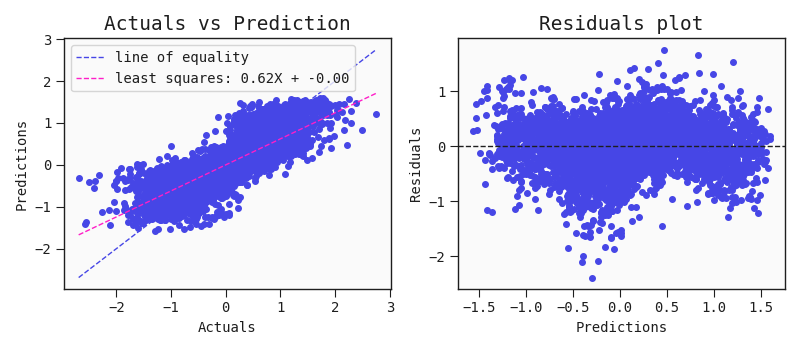
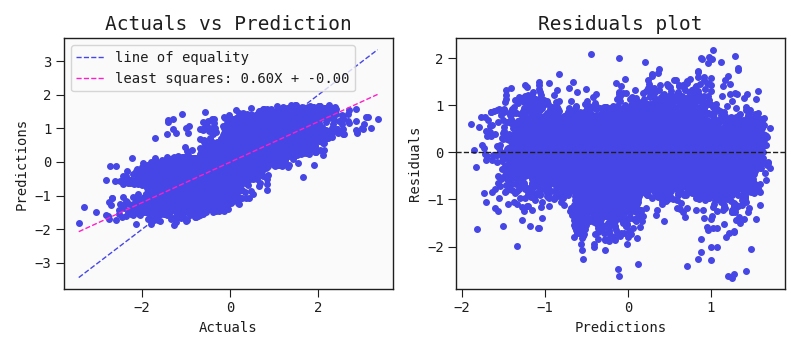

In [8]:
target, model = 'z3_dot', model_z3
model.plot(
    data=data_train[inputs + [target]],
    compare_data=data_test[inputs + [target]]
)

<?xml version="1.0" encoding="utf-8" ?>
<svg baseProfile="full" height="308.0" preserveAspectRatio="none" version="1.1" viewBox="0 0 981 308.0" width="981" xmlns="http://www.w3.org/2000/svg" xmlns:ev="http://www.w3.org/2001/xml-events" xmlns:xlink="http://www.w3.org/1999/xlink"><defs /><svg class="graph" height="215.0" width="711" x="0" y="0"><defs /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="601" y="80.0"><title>z4_dot
linear:
scale=7.401975
scale offset=0.000000
w=-2.618162
bias=0.3447</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="646.0" y="101.5">z4_dot</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="689" y="89.0">0</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="603" y="89.0">linear</text><line stroke="#1E1E1E" x1="571" x2="601" y1="97.5" y2="97.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="481" y="80.0"><title>gaussian</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="526.0" y="101.5">gaussian</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="569" y="89.0">1</text><line stroke="#1E1E1E" x1="451" x2="481" y1="67.5" y2="88.5" /><line stroke="#1E1E1E" x1="451" x2="481" y1="127.5" y2="106.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="361" y="50.0"><title>gaussian</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="406.0" y="71.5">gaussian</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="449" y="59.0">2</text><line stroke="#1E1E1E" x1="331" x2="361" y1="37.5" y2="67.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="241" y="20.0"><title>z2
linear:
scale=0.027635
scale offset=-1.288387
w=-0.391020
bias=0.0657</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="41.5">z2</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="29.0">3</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="243" y="29.0">num</text><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="361" y="110.0"><title>multiply</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="406.0" y="131.5">multiply</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="449" y="119.0">4</text><line stroke="#1E1E1E" x1="331" x2="361" y1="97.5" y2="118.5" /><line stroke="#1E1E1E" x1="331" x2="361" y1="157.5" y2="136.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="241" y="80.0"><title>gaussian</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="101.5">gaussian</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="89.0">5</text><line stroke="#1E1E1E" x1="211" x2="241" y1="67.5" y2="88.5" /><line stroke="#1E1E1E" x1="211" x2="241" y1="127.5" y2="106.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="121" y="50.0"><title>z4
linear:
scale=0.011826
scale offset=-9.178383
w=0.881842
bias=1.0060</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" s
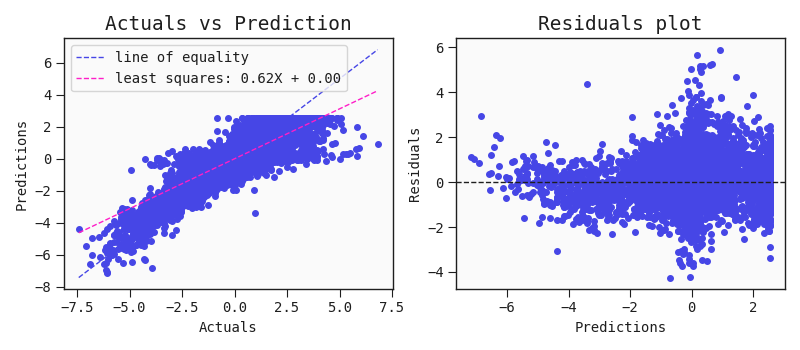
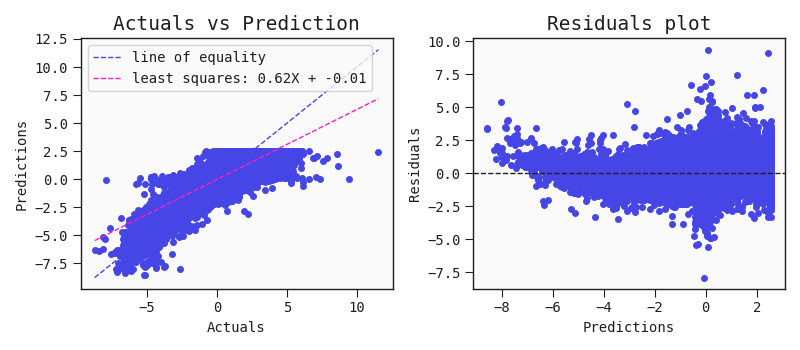

In [12]:
target, model = 'z4_dot', model_z4
model.plot(
    data=data_train[inputs + [target]],
    compare_data=data_test[inputs + [target]]
)

In [13]:
model.sympify(signif=3)

2.55 - 19.4*exp(-2.0*(0.774*T2m + 1.99)**2*exp(-4.0*(0.0104*z4 + 1.1)**2 - 4.0*(0.289*Fs + 0.0375*z2 - 0.191)**2) - 2.0*exp(-4.0*(0.0518 - 0.0108*z2)**2))

<?xml version="1.0" encoding="utf-8" ?>
<svg baseProfile="full" height="368.0" preserveAspectRatio="none" version="1.1" viewBox="0 0 861 368.0" width="861" xmlns="http://www.w3.org/2000/svg" xmlns:ev="http://www.w3.org/2001/xml-events" xmlns:xlink="http://www.w3.org/1999/xlink"><defs /><svg class="graph" height="275.0" width="591" x="0" y="0"><defs /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="481" y="110.0"><title>z1_dot
linear:
scale=7.916145
scale offset=0.000000
w=1.247036
bias=-0.0048</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="526.0" y="131.5">z1_dot</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="569" y="119.0">0</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="483" y="119.0">linear</text><line stroke="#1E1E1E" x1="451" x2="481" y1="127.5" y2="127.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="361" y="110.0"><title>add</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="406.0" y="131.5">add</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="449" y="119.0">1</text><line stroke="#1E1E1E" x1="331" x2="361" y1="97.5" y2="118.5" /><line stroke="#1E1E1E" x1="331" x2="361" y1="157.5" y2="136.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="241" y="80.0"><title>multiply</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="101.5">multiply</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="89.0">2</text><line stroke="#1E1E1E" x1="211" x2="241" y1="37.5" y2="88.5" /><line stroke="#1E1E1E" x1="211" x2="241" y1="97.5" y2="106.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="121" y="20.0"><title>gaussian</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="166.0" y="41.5">gaussian</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="209" y="29.0">3</text><line stroke="#1E1E1E" x1="91" x2="121" y1="97.5" y2="28.5" /><line stroke="#1E1E1E" x1="91" x2="121" y1="157.5" y2="46.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="1" y="80.0"><title>Fl
linear:
scale=0.222298
scale offset=-0.014033
w=-0.350694
bias=0.9168</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="46.0" y="101.5">Fl</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="89" y="89.0">4</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="3" y="89.0">num</text><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="1" y="140.0"><title>z2
linear:
scale=0.025993
scale offset=-0.146317
w=-6.943820
bias=0.1082</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="46.0" y="161.5">z2</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="89" y="149.0">5</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="3" y="149.0">num</text><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="121" y="80.0"><title>Fs
linear:
scale=0.132744
scale of
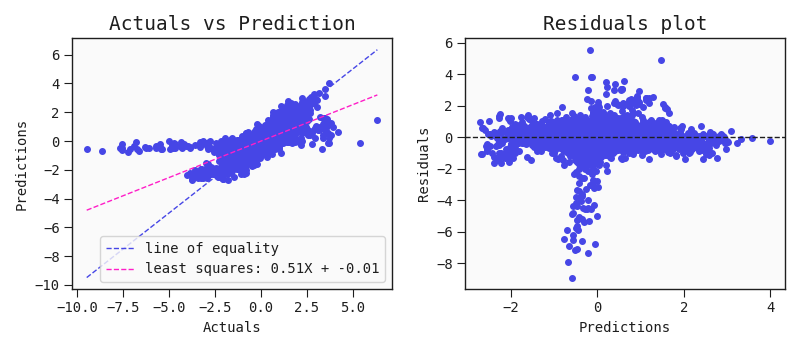
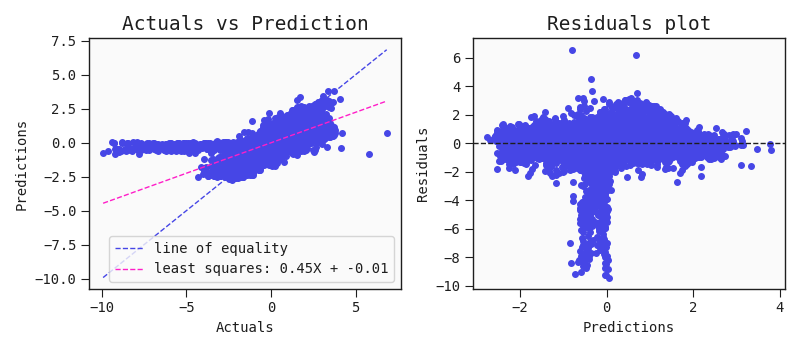

In [26]:
best = models[0]
best.plot(
    data=data_train[inputs + [target]],
    compare_data=data_test[inputs + [target]]
)

In [35]:
models[5].sympify(signif=3)

9.7*(-0.146*Fl - 0.441)*(-0.0137*z3 + exp(-2.0*(-0.0604*Fs - 0.763)**2 - 2.0*(0.0816*z2 + 0.0406)**2) - 0.285)*exp(-2.0*(0.342*Ts - 0.345)**2) + 0.0615

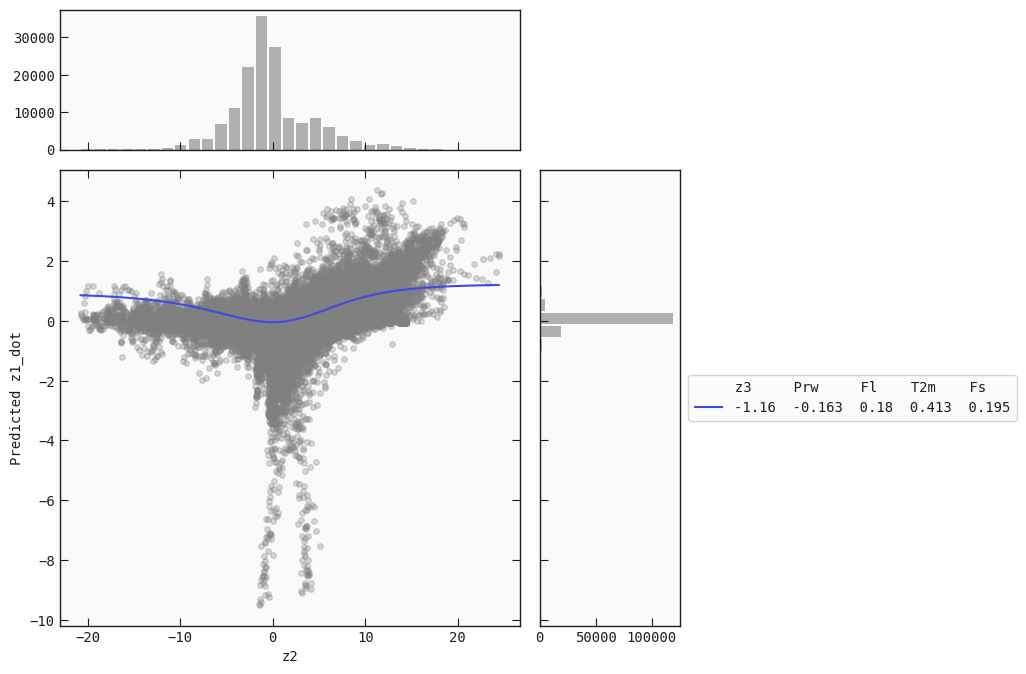

In [9]:
best.plot_response_1d(
    data=data_test[inputs + [target]], by='z2')

In [42]:
taus = np.arange(0, 300)
autocorrs = np.zeros((len(taus), latent_dims))
for i, tau in enumerate(taus):
    autocorrs[i, 0] = data_train.z1_dot.autocorr(lag=tau)
    autocorrs[i, 1] = data_train.z2_dot.autocorr(lag=tau)
    autocorrs[i, 2] = data_train.z3_dot.autocorr(lag=tau)


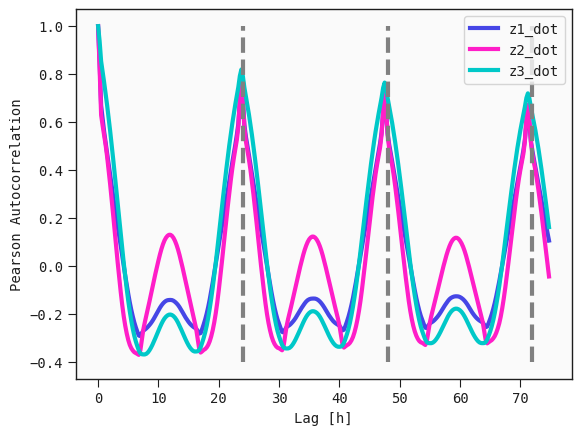

In [43]:
taus_h = taus * 15 / 60  # Convert lags to hours assuming 15 min intervals
plt.plot(taus_h, autocorrs[:, 0], label='z1_dot')
plt.plot(taus_h, autocorrs[:, 1], label='z2_dot')
plt.plot(taus_h, autocorrs[:, 2], label='z3_dot')
plt.legend()
plt.xlabel('Lag [h]')
plt.ylabel('Pearson Autocorrelation')
plt.vlines([24, 48, 72], ymin=-.4, ymax=1.0, colors='gray', linestyles='dashed')  

In [44]:
taus = np.arange(0, 300)
autocorrs = np.zeros((len(taus), latent_dims))
for i, tau in enumerate(taus):
    autocorrs[i, 0] = data_train.Prw.autocorr(lag=tau)
    autocorrs[i, 1] = data_train.T2m.autocorr(lag=tau)
    autocorrs[i, 2] = data_train.Fl.autocorr(lag=tau)

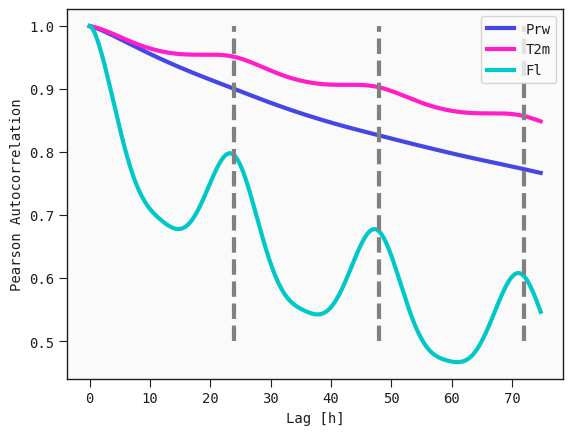

In [46]:
plt.plot(taus_h, autocorrs[:, 0], label='Prw')
plt.plot(taus_h, autocorrs[:, 1], label='T2m')
plt.plot(taus_h, autocorrs[:, 2], label='Fl')
plt.legend()
plt.xlabel('Lag [h]')
plt.ylabel('Pearson Autocorrelation')
plt.vlines([24, 48, 72], ymin=.5, ymax=1.0, colors='gray', linestyles='dashed')  